# <font color='blue'> 현지실사 대상업체 선정 모델
<img src = 'https://images.unsplash.com/photo-1564048171305-0dce5c555dbb?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxzZWFyY2h8Mnx8Y2xvbmV8ZW58MHx8MHx8&auto=format&fit=crop&w=500&q=60'>

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
plt.rcParams['axes.unicode_minus'] = False

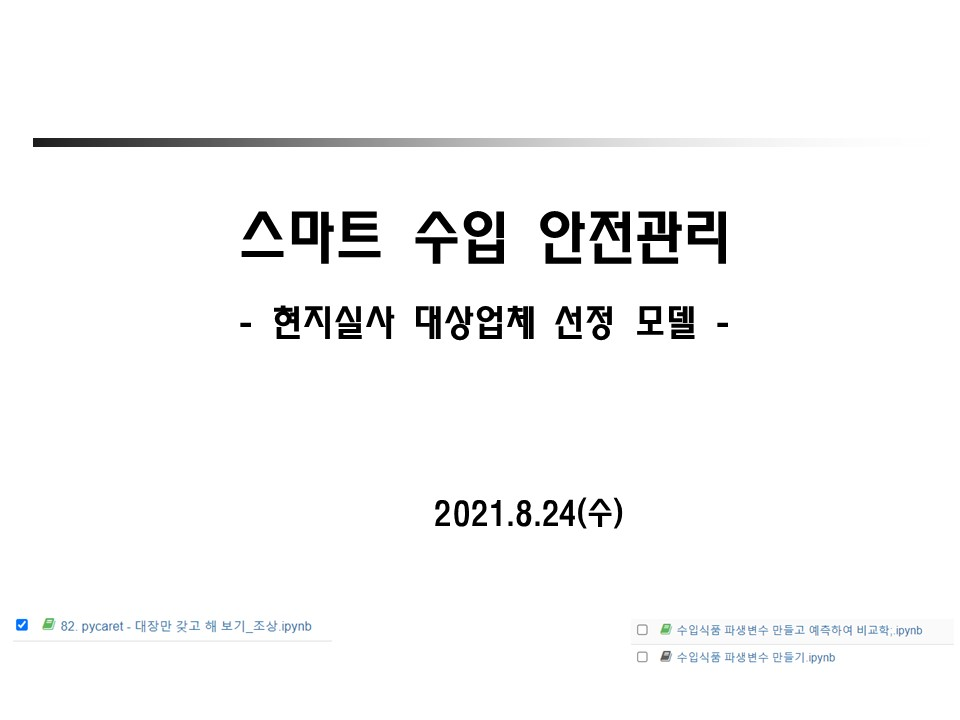

In [2]:
from IPython.display import Image
width=900; height=800
img_path = r'D:\smart food\현지실사\202208_08_24_현지실사 예측모형'
Image(filename= img_path + '/슬라이드1.JPG', width=width, height=height)

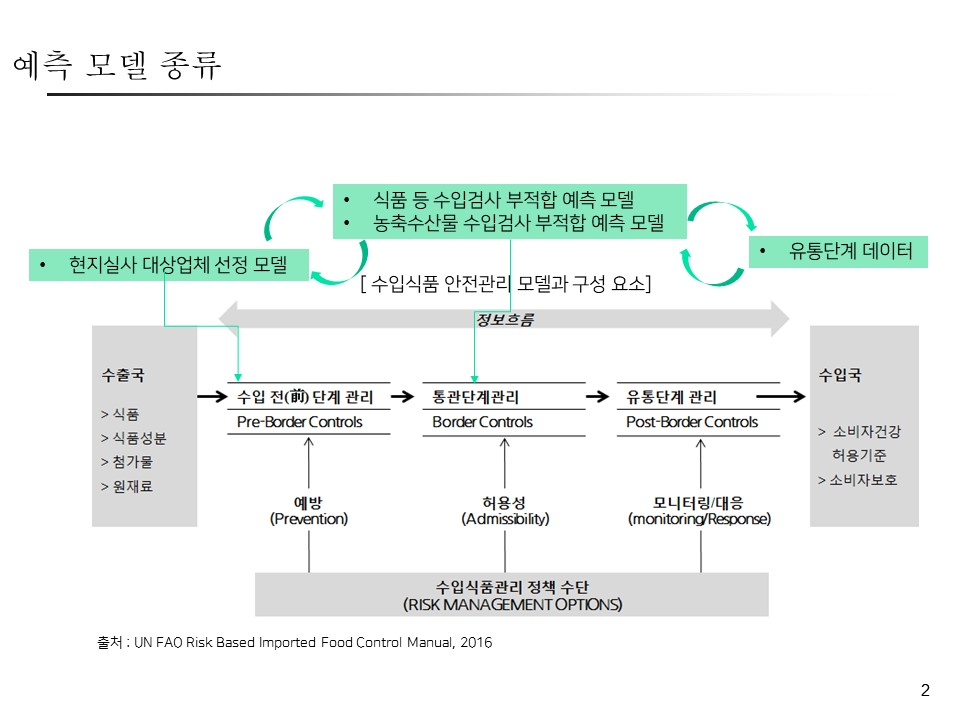

In [3]:
Image(filename= img_path + '/슬라이드2.JPG', width=width, height=height)

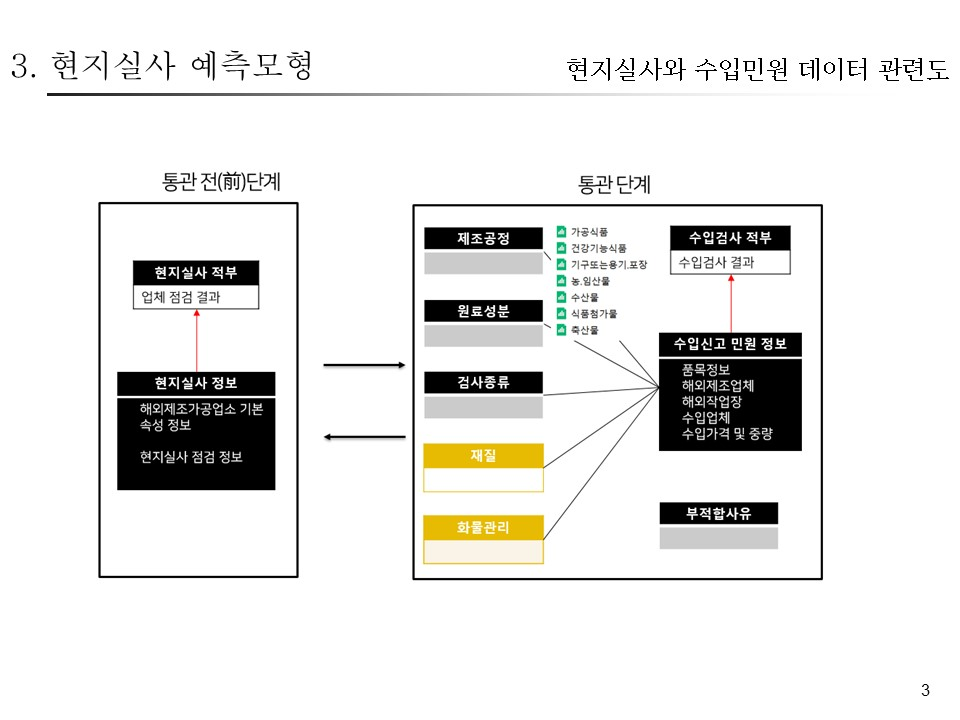

In [4]:
Image(filename= img_path + '/슬라이드3.JPG', width=width, height=height)

# 수입식품안전관리 특별법 ( 약칭: 수입식품법 )
수입식품안전관리 특별법
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220218&lsiSeq=234855#0000

수입식품안전관리 특별법 시행령
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220218&lsiSeq=240329#0000

수입식품안전관리 특별법 시행규칙
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220701&lsiSeq=233697#0000

## 해외제조업소 등록신청서
### 해외제조가공업소 기본 속성 정보
법 제5조(해외제조업소 등록) ① 수입식품등을 국내로 수입하려는 자 또는 해외제조업소의 설치ㆍ운영자(이하 “수입자등”이라 한다)는 해당 해외제조업소의 명칭, 소재지 및 생산 품목 등 총리령으로 정하는 사항을 제20조에 따른 수입신고 전까지 식품의약품안전처장에게 등록하여야 한다.

<img src='https://www.law.go.kr/LSW/flDownload.do?flSeq=113540777'>

### 해외제조업소 점검표
법 제6조(해외제조업소의 현지실사) ① 식품의약품안전처장은 다음 각 호의 어느 하나에 해당하는 경우에는 수출국 정부 또는 해외제조업소와 사전에 협의를 거쳐 해외제조업소에 대하여 현지실사를 할 수 있다.

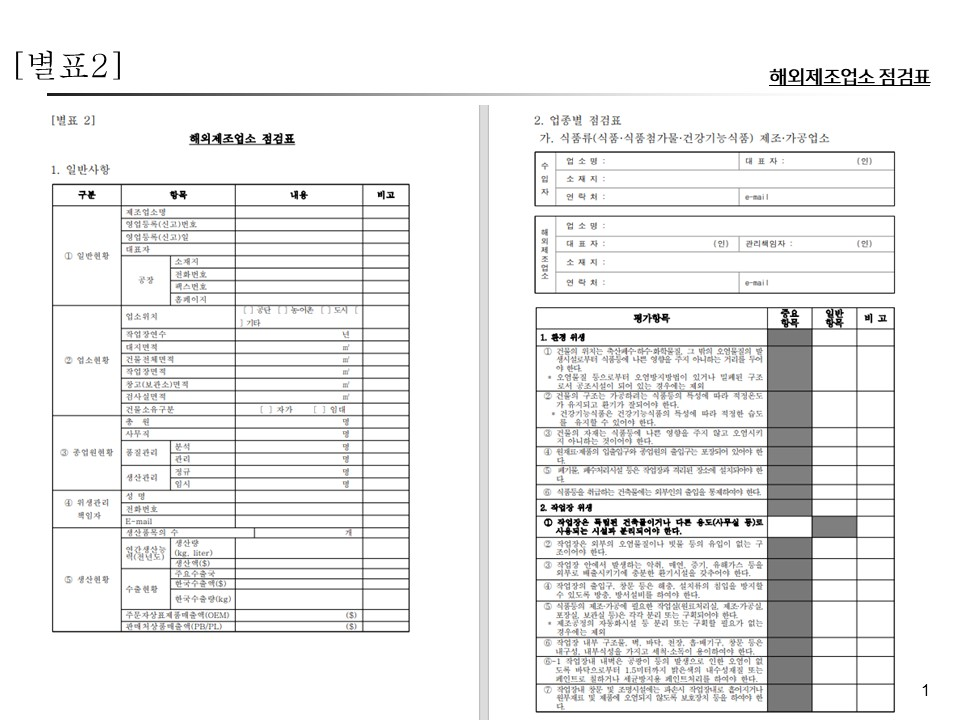

In [7]:
Image(filename= r'D:\smart food\현지실사\202208_08_24_현지실사 예측모형\해외업소점검표' + '/슬라이드1.JPG', width=1200, height=1200)

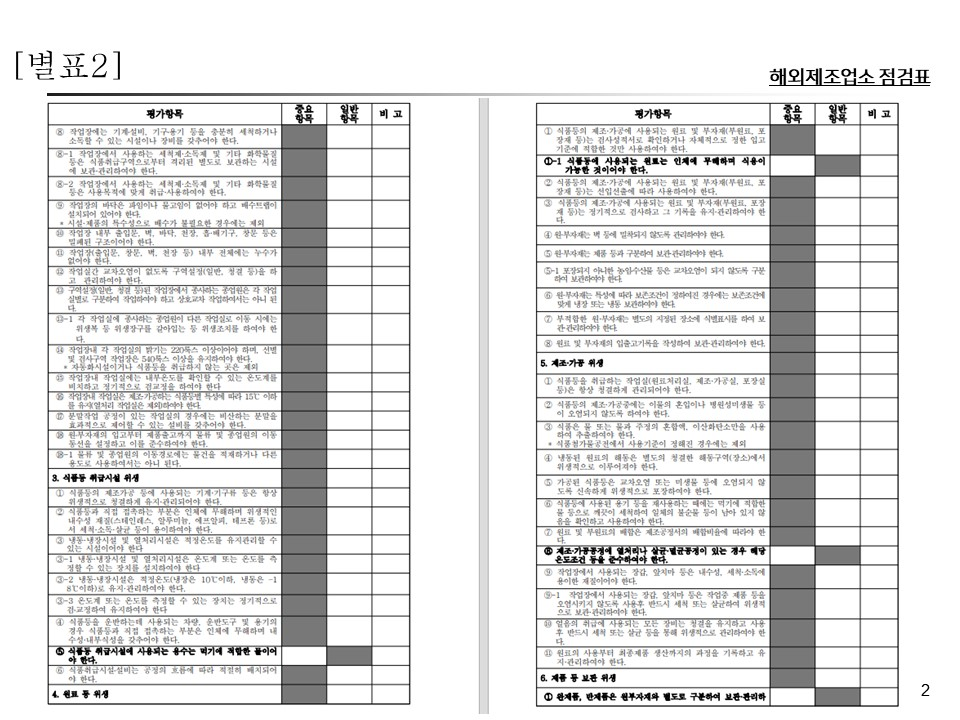

In [8]:
Image(filename= r'D:\smart food\현지실사\202208_08_24_현지실사 예측모형\해외업소점검표' + '/슬라이드2.JPG', width=1200, height=1200)

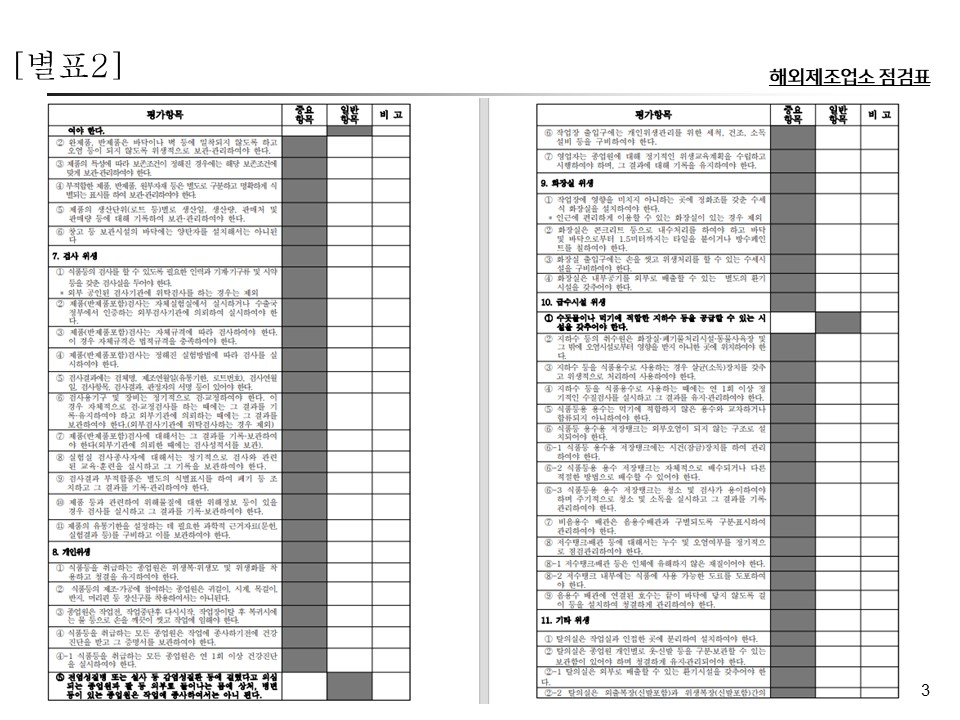

In [9]:
Image(filename= r'D:\smart food\현지실사\202208_08_24_현지실사 예측모형\해외업소점검표' + '/슬라이드3.JPG', width=1200, height=1200)

# 현지실사관련 데이터 현황

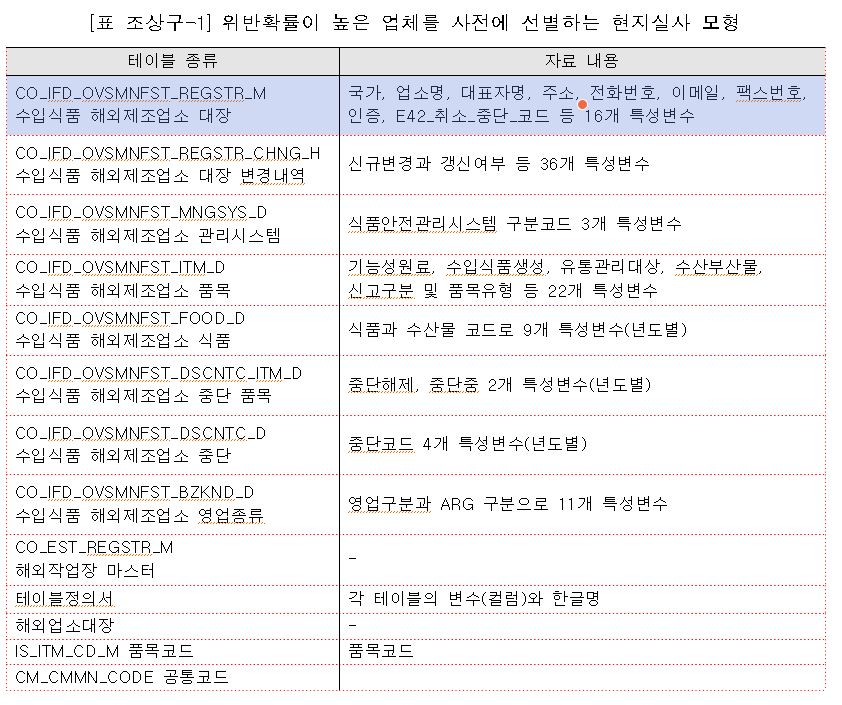

In [5]:
Image(filename= img_path + '/전체테이블.JPG', width=600, height=400)

### 데이터전처리

In [6]:
path = r'D:\smart food\현지실사\2022_2_현지실사\working_ml'
path_01 = r'D:\smart food\현지실사\2022_2_현지실사\working'
import glob
glob.glob(path + '/*.pkl')
glob.glob(path_01 + '/*.*')

['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\data_01_대장.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\data_02_WorldBank.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\data_03_대장변경.pkl']

['D:\\smart food\\현지실사\\2022_2_현지실사\\working\\11. 대장_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\12. 대장_변경내역_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\13. 관리시스템_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\14. 품목_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\15. 식품_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\16. 중단품목_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\17. 중단(수입)_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\18. 영업종류_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\22. 수입민원_업소별_품목특성_gzip',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\33. WorldBank_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\41. 품목코드_특성_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\51. 현지실사결과_gzip.pkl']

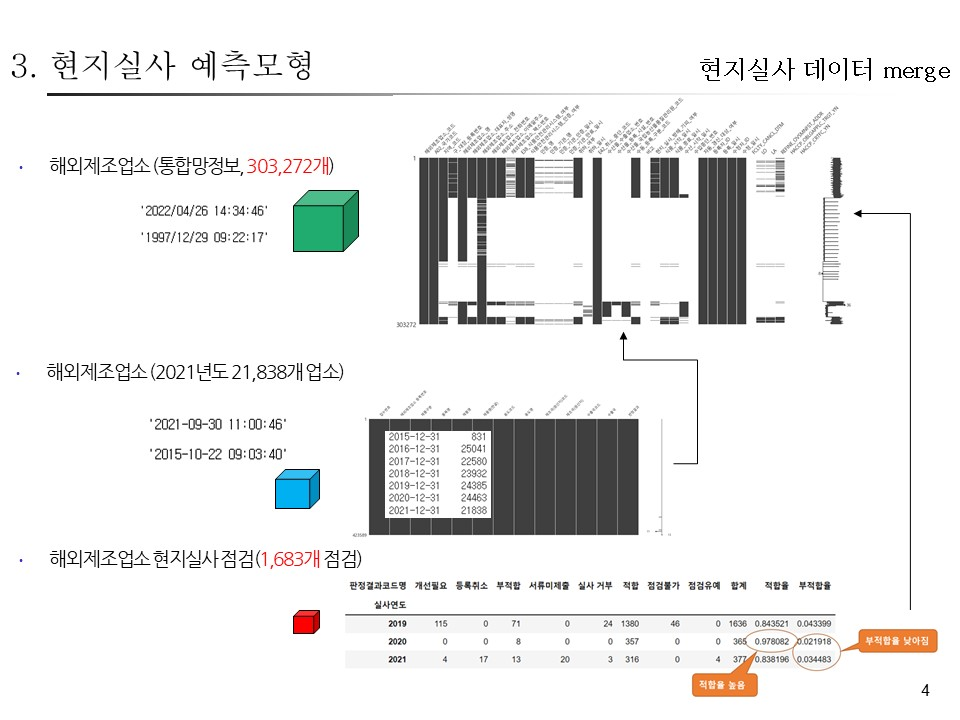

In [7]:
Image(filename= img_path + '/슬라이드4.JPG', width=width, height=height)

## 해외제조업소 대장 전처리

In [8]:
path_02=r'D:\smart food\현지실사\2022_2_현지실사\pickles'
df_maker = pd.read_pickle(path_02 + '/해외제조업소_대장_gzip.pkl', compression='gzip')
df_maker.head()
df_maker.shape

,해외제조업소_코드,A02_국가코드,지역_코드,구_대장_등록번호,해외제조업소_명,해외제조업소_대표자_성명,해외제조업소_주소,해외제조업소_전화번호,해외제조업소_이메일주소,해외제조업소_팩스번호,...,등록자_ID,등록_일시,수정자_ID,수정_일시,FCLTY_CANCL_DTM,LO,LA,REFINE_OVSMNFST_ADDR,HACCP_OBLGAPPLC_TRGT_YN,HACCP_CRTFC_YN
0,CN000095353,CN,CN-JS,NaN,"LIANYUNGANG YINGJI AQUATIC PRODUCTS CO., LTD",ZHENG YINGJI,DONGZHENG VILLAGE ，SONGZHUANG TOWN，GANYU DISTR...,8613179598868,hanchangyuwang@hotmail.com,NaN,...,30040192,2020/03/23 17:36:14,30040192,2020/03/23 17:36:14,NaN,NaN,NaN,NaN,NaN,NaN
1,CN000095354,CN,CN-JS,NaN,JIANGYIN YUANXIANG TEXTILE TECHNOLOGY CO. LTD,QIAN ZHIBIN,"NO.28, HUAYUAN ROAD, XINGONG VILLAGE, GUSHAN T...",86051086323228,1915718832@qq.com,NaN,...,30040192,2020/03/23 17:43:54,30040192,2020/03/23 17:43:54,NaN,NaN,NaN,"NO.28 HUA YUAN LU, XINGONG VILLAGE, GUSHANZHEN...",NaN,NaN
2,JP000022788,JP,JP-01,NaN,"FINE CO., LTD",MR. SHINTARO SETO,"8-123, NISHI HAMACHO, NEMURO-CITY, HIOKKAIDO, ...",81153223501,info@kanese.co.jp,NaN,...,30040192,2020/03/24 14:34:32,30040192,2020/03/24 14:34:32,NaN,NaN,NaN,"8-123, NISHIHAMACHO, NEMURO SHI, HOKKAIDO, 087...",NaN,NaN
3,CN000095360,CN,CN-AH,NaN,MAANSHAN FEIYANG ENVIRONMENTAL PROTECTION CONT...,GAO ZHONG KU,"BUILDING 5, NO.1769, HONGQI SOUTH ROAD, MAANSH...",863127828188,yangmd@yihchina.com,NaN,...,30040192,2020/03/24 16:38:52,30040192,2020/03/24 16:38:52,NaN,NaN,NaN,"1769, 5 HONGQI S RD, YUSHAN QU, MAANSHAN SHI, ...",NaN,NaN
4,CN000095364,CN,CN-ZJ,NaN,YIWU SHI AIMO DIANZI KEJI YOUXIAN GONGSI,BIEHUI,"QINGKOU EAST DISTRICT, JIANGDONG STREET, YIWU ...",8613735897567,1098570241@qq.com,NaN,...,30040192,2020/03/25 15:03:05,88870003,2022/03/04 17:20:07,NaN,NaN,NaN,"QING KOU LU, YIWU SHI, JINHUA SHI, ZHEJIANG SH...",NaN,NaN


(303272, 40)

<AxesSubplot:>

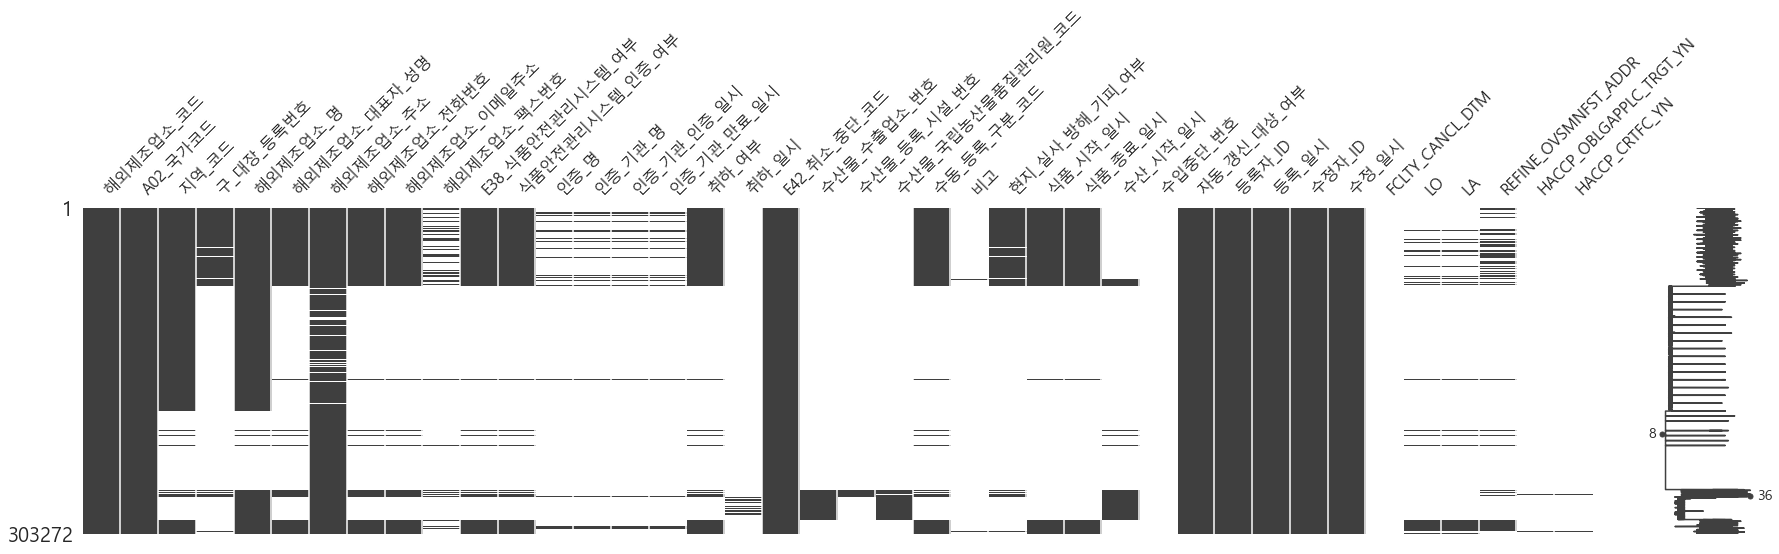

In [9]:
import missingno as msn
msn.matrix(df_maker, figsize=(30,6))

In [10]:
print('분석시작일 : ', pd.to_datetime(df_maker['식품_시작_일시']).min())
print('분석종료일 : ', pd.to_datetime(df_maker['식품_시작_일시']).max())
print('전체 제조가공업소는 ', df_maker['해외제조업소_코드'].nunique(), '개 업소')

분석시작일 :  2016-02-05 00:00:00
분석종료일 :  2022-04-26 14:34:46
전체 제조가공업소는  303272 개 업소


## 입력변수 선택 (예측모형에 투입될 변수)

In [11]:
col_dict = {'해외제조업소_명':'업소명',
            '해외제조업소_대표자_성명':'대표자성명', 
            '해외제조업소_주소':'주소', 
            '해외제조업소_전화번호':'전화번호', 
            '해외제조업소_이메일주소':'이메일',
            '해외제조업소_팩스번호':'팩스',
            '식품안전관리시스템_인증_여부':'인증',
            '인증_명':'공식인증',
            '현지_실사_방해_기피_여부':'방해'}

In [12]:
def summary(df) :
    tf = pd.DataFrame({'데이터형태(dtypes)' : df.dtypes,
                       '결측치 수(null)' : df.isnull().sum(),
                       '결측치 비율(%)' : (df.isnull().sum()/len(df)).round(2),
                       '고유값 수(nunique)' : df.nunique(),
                      })
    for col in tf.index:
        tf.loc[col, '자료 내용(contents)'] = str(df[col].unique()[0:5])
        
    return tf

In [13]:
summary(df_maker[col_dict])

,데이터형태(dtypes),결측치 수(null),결측치 비율(%),고유값 수(nunique),자료 내용(contents)
해외제조업소_명,object,72435,0.24,205801,"['LIANYUNGANG YINGJI AQUATIC PRODUCTS CO., LTD..."
해외제조업소_대표자_성명,object,208543,0.69,79081,['ZHENG YINGJI' 'QIAN ZHIBIN' 'MR. SHINTARO SE...
해외제조업소_주소,object,13284,0.04,269669,['DONGZHENG VILLAGE ，SONGZHUANG TOWN，GANYU DIS...
해외제조업소_전화번호,object,208697,0.69,81361,['8613179598868' '86051086323228' '81153223501...
해외제조업소_이메일주소,object,208605,0.69,77826,['hanchangyuwang@hotmail.com' '1915718832@qq.c...
해외제조업소_팩스번호,object,268792,0.89,29567,[nan '8657684251299' '88041813836' '3355650542...
식품안전관리시스템_인증_여부,object,209475,0.69,2,['N' 'Y' nan]
인증_명,object,286995,0.95,5842,[nan 'HACCP' 'ISO9001:2015' 'FSSC22000' 'RoHS2 ']
현지_실사_방해_기피_여부,object,225899,0.74,2,[nan 'N' 'Y']


<AxesSubplot:>

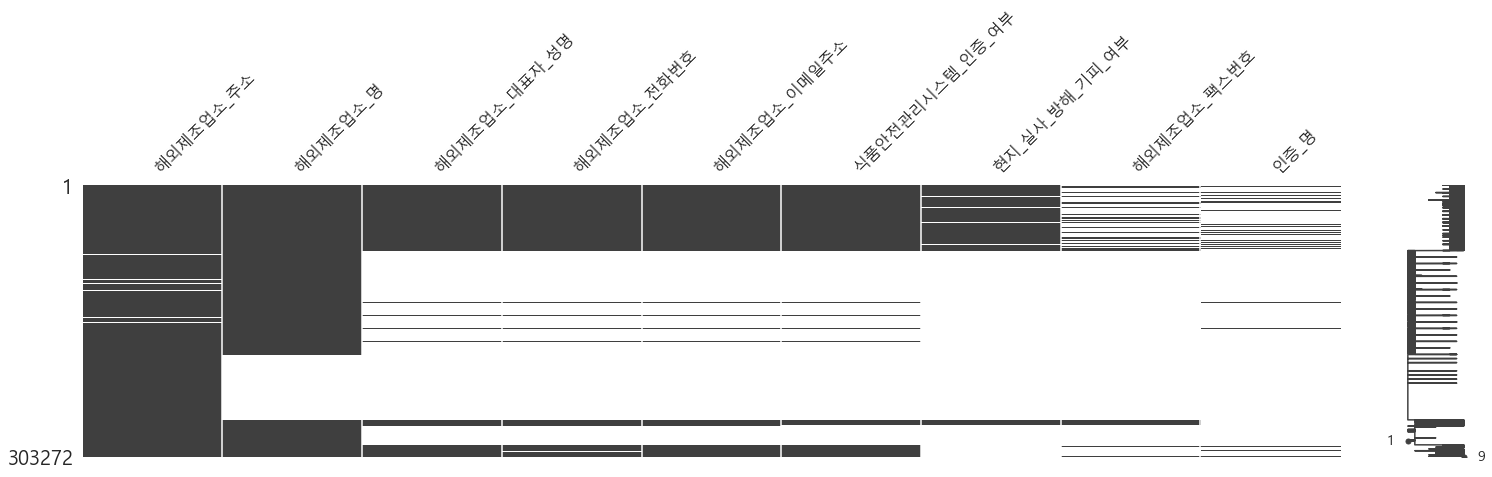

In [14]:
msn.matrix(df_maker[summary(df_maker[col_dict]).sort_values('결측치 비율(%)').index], figsize=(25,5))

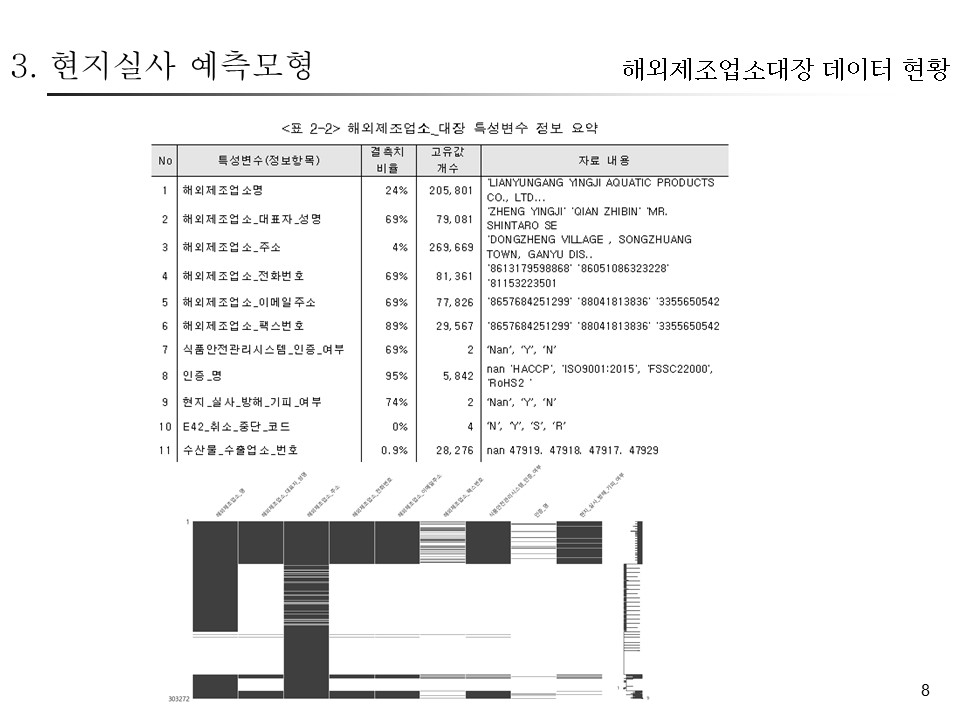

In [15]:
Image(filename= img_path + '/슬라이드8.JPG', width=width, height=height)

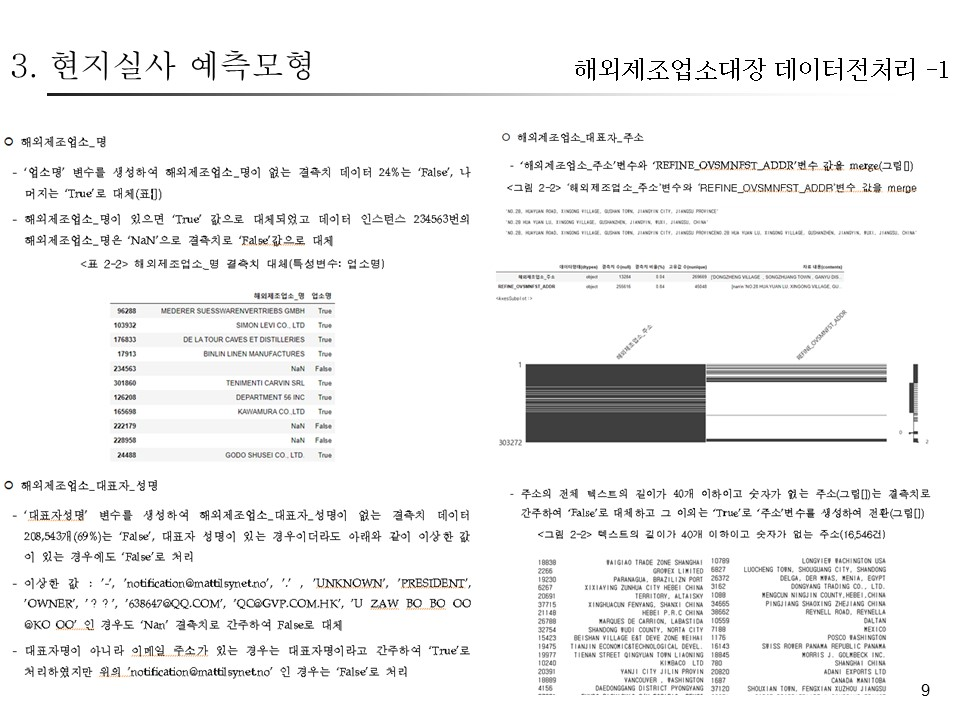

In [16]:
Image(filename= img_path + '/슬라이드9.JPG', width=1200, height=1000)

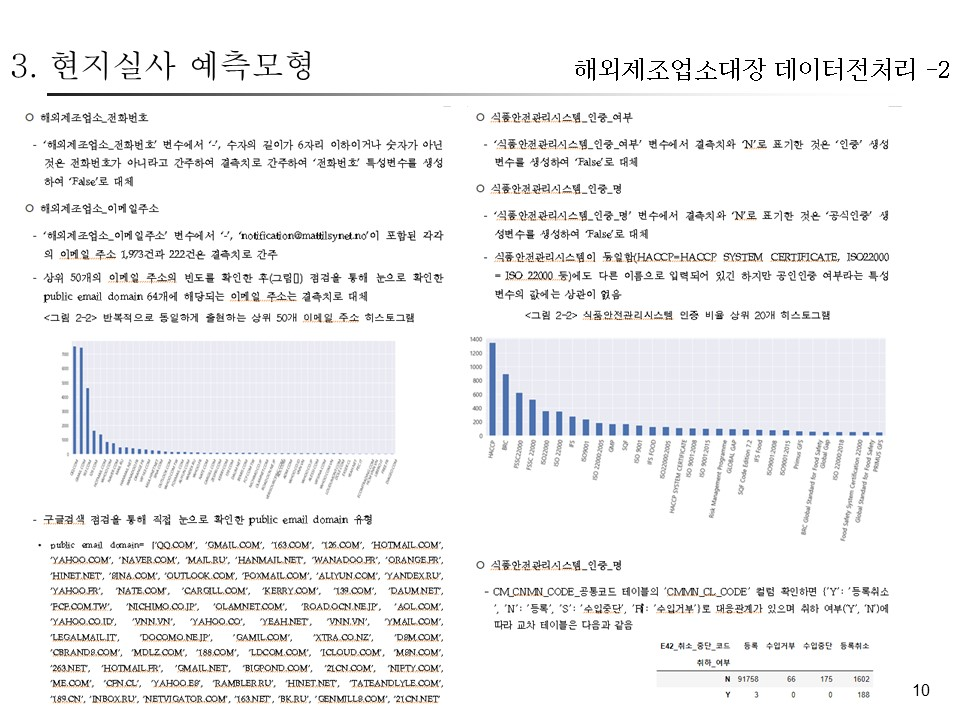

In [17]:
Image(filename= img_path + '/슬라이드10.JPG', width=1200, height=1000)

## 해외제조업소대장 전처리 완료//

,A02_국가코드,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,,,
CN000095375,CN,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
CN000010833,CN,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
VN000000420,VN,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
JP000002818,JP,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
TH000001271,TH,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,DE,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
US000000418,US,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
US000000318,US,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False


,A02_국가코드,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,,,
CN000095375,CN,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0
CN000010833,CN,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0
VN000000420,VN,1,1,1,1,1,1,1,0,0,0,1,0,0,0,0
JP000002818,JP,1,1,1,1,1,1,0,0,0,0,1,0,0,0,0
TH000001271,TH,1,1,1,1,1,0,1,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,DE,1,1,1,1,1,1,0,1,1,0,1,0,0,0,0
US000000418,US,1,1,1,1,1,1,0,1,1,0,1,0,0,0,0
US000000318,US,1,1,1,1,1,1,1,1,1,0,1,0,0,0,0


<AxesSubplot:>

적합     83.362937
부적합    16.637063
Name: target, dtype: float64

적합     1408
부적합     281
Name: target, dtype: int64

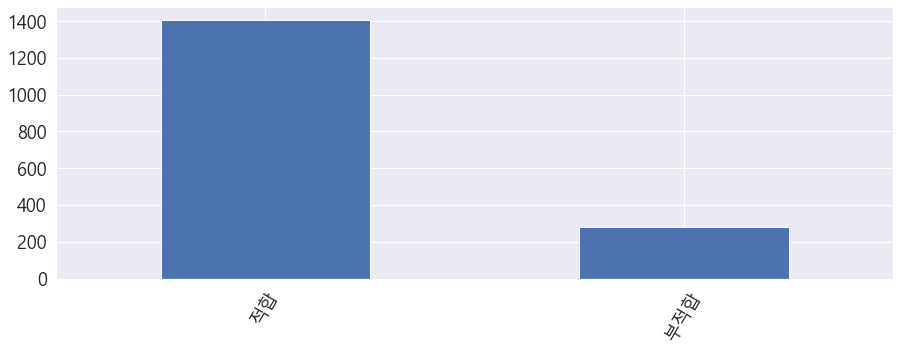

In [18]:
data = pd.read_pickle(path + '/data_01_대장.pkl').set_index('해외제조업소_코드')
data
data*1
data['target'].map({False: '적합', True: '부적합'}).value_counts().plot(rot =60, kind='bar', figsize=(15,5), fontsize=18)
data['target'].map({False: '적합', True: '부적합'}).value_counts(normalize=True)*100
data['target'].map({False: '적합', True: '부적합'}).value_counts()

DecisionTreeClassifier()

<Figure size 1800x576 with 0 Axes>

No handles with labels found to put in legend.


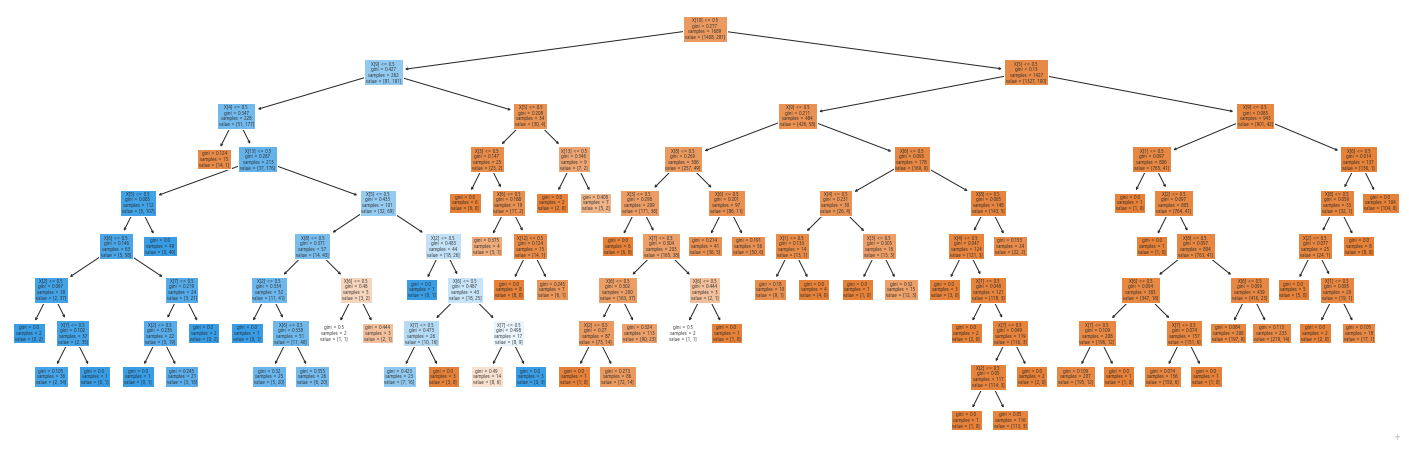

In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
clf = DecisionTreeClassifier(random_state=11)
X = data.drop(['A02_국가코드', 'target'], axis=1)
y = data.target
dt = DecisionTreeClassifier()
dt.fit(X, y)
plt.figure(figsize=(25,8))
ax = plot_tree(dt, filled=True)
plt.legend(loc='lower right', borderpad=0, handletextpad=0)

## 국가별 현황
### 국가코드를 한글명으로 공통코드에서 MAPPING

In [26]:
path_04 =r'D:\smart food\현지실사\2022_2_현지실사\코드테이블'
match = pd.read_excel(path_04  + '/CM_CMMN_CODE 공통코드.xlsx', usecols = ['CMMN_CL_CODE', 'CMMN_CODE', 'CMMN_CODE_NM'])
match = match[match['CMMN_CL_CODE'] == 'MG004']
match = dict(zip(match.CMMN_CODE, match.CMMN_CODE_NM))

In [27]:
data['A02_국가코드'] = data['A02_국가코드'].map(match)

현지실사 방문 국가는 45 개국


<AxesSubplot:>

Text(0.5, 1.0, '국가별 현지실사 방문회수')

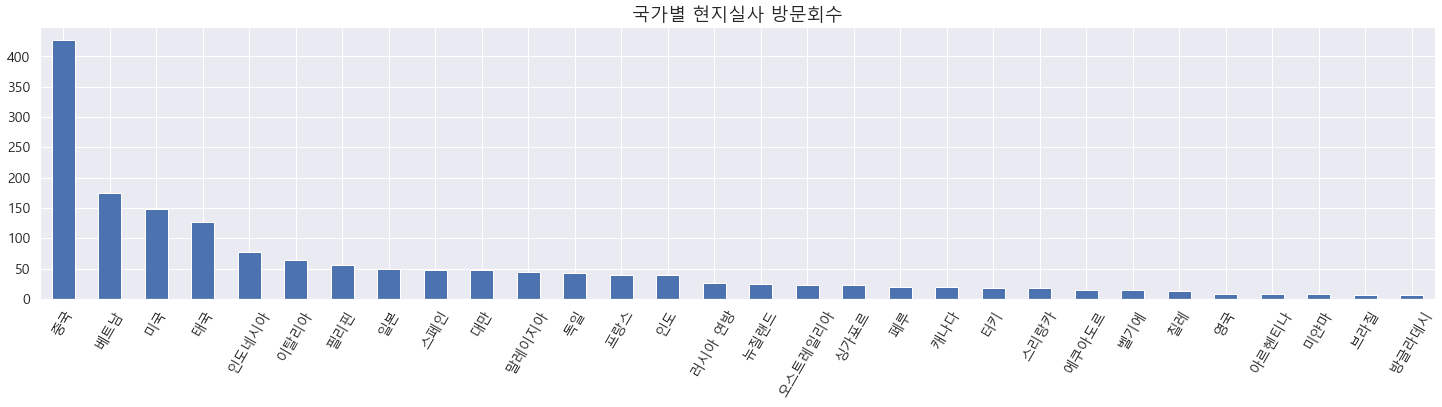

In [28]:
print('현지실사 방문 국가는', data['A02_국가코드'].nunique(), '개국')
data['A02_국가코드'].value_counts().nlargest(30).plot(kind='bar', rot=60, figsize=(25,5), fontsize=14)
plt.title('국가별 현지실사 방문회수', fontsize=18)

<AxesSubplot:xlabel='A02_국가코드'>

Text(0.5, 1.0, '국가별 현지실사 부적합율')

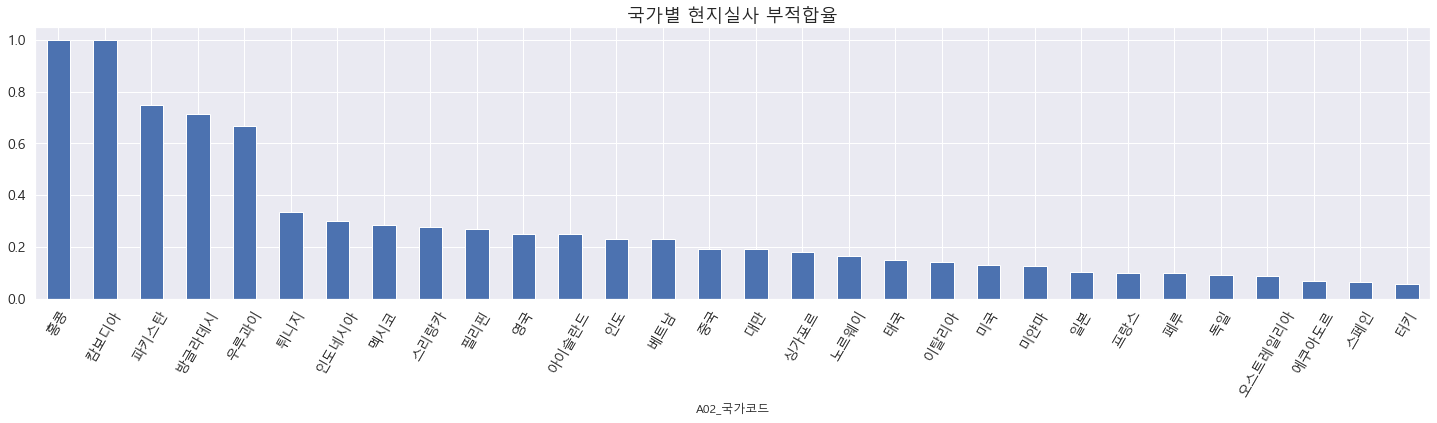

In [29]:
data.groupby('A02_국가코드')['target'].mean().sort_values(ascending=False).nlargest(30).plot(kind='bar', rot=60, figsize=(25,5), fontsize=14)
plt.title('국가별 현지실사 부적합율', fontsize=18)

In [30]:
country = data.groupby('A02_국가코드').agg({'target': 'mean', '업소명':'count'})
country.columns = ['부적합율', '현지실사 건 수']
country['부적합건수'] = country['현지실사 건 수']* country['부적합율']
country.sort_values('부적합율', ascending=False).head(10)
country.sort_values('부적합율', ascending=False).tail(5)

,부적합율,현지실사 건 수,부적합건수
A02_국가코드,,,
홍콩,1.000000,3,3.0
캄보디아,1.000000,2,2.0
파키스탄,0.750000,4,3.0
방글라데시,0.714286,7,5.0
우루과이,0.666667,3,2.0
튀니지,0.333333,3,1.0
인도네시아,0.298701,77,23.0
멕시코,0.285714,7,2.0
스리랑카,0.277778,18,5.0


,부적합율,현지실사 건 수,부적합건수
A02_국가코드,,,
캐나다,0.0,19,0.0
스위스,0.0,5,0.0
칠레,0.0,13,0.0
아르헨티나,0.0,8,0.0
남아프리카,0.0,3,0.0


### <font color='purple'> ! TIP Target encoder with prior smoothing
https://contrib.scikit-learn.org/category_encoders/targetencoder.html

In [31]:
from category_encoders import TargetEncoder
encoder = TargetEncoder()
encoder.fit_transform(data['A02_국가코드'], data['target']).sort_values('A02_국가코드').tail()

,A02_국가코드
해외제조업소_코드,
KH000000108,0.775803
KH000000141,0.775803
HK000001063,0.900629
HK000001116,0.900629
HK000001128,0.900629


In [32]:
encoder = TargetEncoder(smoothing=0.7)
encoder.fit_transform(data['A02_국가코드'], data['target']).sort_values('A02_국가코드').tail()

,A02_국가코드
해외제조업소_코드,
KH000000108,0.838842
KH000000141,0.838842
HK000001063,0.954723
HK000001116,0.954723
HK000001128,0.954723


## Feature Selection
### Theil_U

In [33]:
import math
import scipy.stats as ss
from collections import Counter

def conditional_entropy(x,y):
    # entropy of x given y
    y_counter = Counter(y)
    xy_counter = Counter(list(zip(x,y)))
    total_occurrences = sum(y_counter.values())
    entropy = 0
    for xy in xy_counter.keys():
        p_xy = xy_counter[xy] / total_occurrences
        p_y = y_counter[xy[1]] / total_occurrences
        entropy += p_xy * math.log(p_y/p_xy)
    return entropy

def theil_u(x,y):
    s_xy = conditional_entropy(x,y)
    x_counter = Counter(x)
    total_occurrences = sum(x_counter.values())
    p_x = list(map(lambda n: n/total_occurrences, x_counter.values()))
    s_x = ss.entropy(p_x)
    if s_x == 0:
        return 1
    else:
        return (s_x - s_xy) / s_x

In [34]:
def cat_corr (df):
    
    for j in range(0,len(columns)):
        u = theil_u(df['target'].tolist(),df[columns[j]].tolist())
        theilu.loc[:,columns[j]] = u
    theilu.fillna(value=np.nan,inplace=True)

    plt.figure(figsize=(30,2))
    sns.set(font_scale=1.4)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    sns.heatmap(theilu,annot=True,fmt='.2f', annot_kws={"size": 12})

    plt.show()

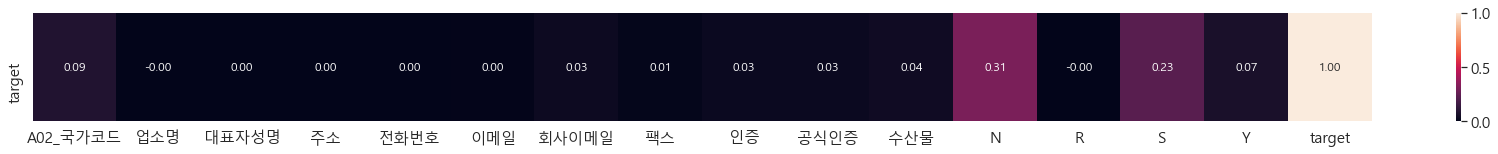

In [35]:
columns = data.columns
theilu = pd.DataFrame(index=['target'], columns= columns)

cat_corr(data)

# A02_국가코드를 제거하면 정확성이 높아짐
### 업소명과 R 변수 만 제거

In [36]:
data.drop(['업소명','R'], axis=1, inplace=True)
#data.drop(['A02_국가코드', '업소명','R'], axis=1, inplace=True)
#data.drop(['업소명','N', 'R', 'S', 'Y'], axis=1, inplace=True)

In [37]:
data.head()

,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,
CN000095375,중국,True,True,True,True,False,False,False,False,False,True,False,False,False
CN000010833,중국,True,True,True,True,False,False,False,False,False,True,False,False,False
VN000000420,베트남,True,True,True,True,True,True,False,False,False,True,False,False,False
JP000002818,일본,True,True,True,True,True,False,False,False,False,True,False,False,False
TH000001271,태국,True,True,True,True,False,True,True,True,False,False,False,True,False


In [38]:
from category_encoders import WOEEncoder
woe = WOEEncoder()
woe.fit_transform(data['A02_국가코드'], data['target'])

,A02_국가코드
해외제조업소_코드,
CN000095375,0.178300
CN000010833,0.178300
VN000000420,0.414195
JP000002818,-0.409005
TH000001271,-0.089718
...,...
DE000000001,-0.473543
US000000418,-0.265904
US000000318,-0.265904


## 데이터 형태에 따라 구분(교차검증과 하이퍼파라미터 준비)

In [39]:
data.dtypes
numeric_features = data.drop(['target'], axis=1).select_dtypes(include=['int64', 'float64']).columns
categorical_features  = data.drop(['target'], axis=1).select_dtypes(include=['object']).columns
categorical_features

A02_국가코드    object
대표자성명         bool
주소            bool
전화번호          bool
이메일           bool
회사이메일         bool
팩스            bool
인증            bool
공식인증          bool
수산물           bool
N             bool
S             bool
Y             bool
target        bool
dtype: object

Index(['A02_국가코드'], dtype='object')

## 훈련, 검증, 테스트 데이터 나누기

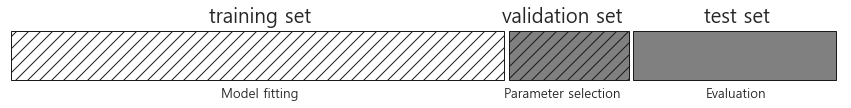

In [40]:
#! pip install mglearn
import mglearn
mglearn.plots.plot_threefold_split()

In [41]:
X = data.iloc[:, :-1]
y = data.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y,  random_state=12)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, stratify=y_train, random_state=12)

print('훈련데이터(traing set) Data(X,y)크기와 부적합율')
[X_train.shape, y_train.shape]
(y_train.sum()/len(y_train)).round(4)
print('검증데이터(validation set) Data(X,y)크기와 부적합율')
[X_val.shape, y_val.shape]
(y_val.sum()/len(y_val)).round(4)
print('테스트데이터(test set) Data(X,y)크기와 부적합율')
[X_test.shape, y_test.shape]
(y_test.sum()/len(y_test)).round(4)

훈련데이터(traing set) Data(X,y)크기와 부적합율


[(1080, 13), (1080,)]

0.1667

검증데이터(validation set) Data(X,y)크기와 부적합율


[(271, 13), (271,)]

0.1661

테스트데이터(test set) Data(X,y)크기와 부적합율


[(338, 13), (338,)]

0.1657

## Cross validation and Hyperparameter tuninig

In [42]:
from sklearn import ensemble 
from sklearn.linear_model import LogisticRegression

classifiers = {}
classifiers.update({'Logistic regression': LogisticRegression()})
classifiers.update({'Random Forest': ensemble.RandomForestClassifier()})
classifiers.update({'Gradient Boosting': ensemble.GradientBoostingClassifier()})
classifiers

{'Logistic regression': LogisticRegression(),
 'Random Forest': RandomForestClassifier(),
 'Gradient Boosting': GradientBoostingClassifier()}

## 손실함수 조정 (예측오류에 차별적으로 Penalty를 부여)
- 'classifier__class_weight': [None, 'balanced'],
- SMOTE와 같은 효과(1과 0값을 SMOTE?)
<img src='https://i.stack.imgur.com/0rA2S.png' width=400>

$L= λ_1* −ylog(p)  − λ_2 ∗ (1−y)log(1−𝑝)$  
$λ_1, λ_2$ = 𝑝𝑒𝑛𝑎𝑙𝑡𝑦 

**$λ_1$ = 10, $λ_2$ =1**

**- FP는 10, FN는 1의 Penalty를 부여**

In [43]:
parameters = {}

parameters.update({'Logistic regression': 
{
'classifier__C': np.logspace(-4, 4, 20), 
'classifier__class_weight': [None, 'balanced'],
'classifier__penalty': ['l1', 'l2']    
}})

parameters.update({'Random Forest': 
{ 
'classifier__n_estimators': [50, 100, 150, 200, 250, 300],
'classifier__class_weight': [None, 'balanced'],
'classifier__max_features': ['auto', 'sqrt', 'log2'],
'classifier__max_depth' : [int(x) for x in np.linspace(3, 50, 20)],
'classifier__min_samples_split': [0.005, 0.01, 0.05, 0.10],
'classifier__min_samples_leaf': [0.005, 0.01, 0.05, 0.10],
'classifier__criterion' :['gini', 'entropy'],
'classifier__n_jobs': [-1]
}})

parameters.update({'Gradient Boosting': 
{ 
'classifier__learning_rate':[0.15,0.1,0.05,0.01,0.005,0.001], 
'classifier__n_estimators': [200],
'classifier__max_depth': [2,3,4,5,6],
'classifier__min_samples_split': [0.005, 0.01, 0.05, 0.10],
'classifier__min_samples_leaf': [0.005, 0.01, 0.05, 0.10],
'classifier__max_features': ['auto', 'sqrt', 'log2'],
'classifier__subsample': [0.8, 0.9, 1]
}})


## <font color='blue'> 선 데이터전처리 후 교차검증과 Hyperparameters
### 데이터전처리는 pipeline 적용 (즉 CV마다 woe를 적용)
### 3 Folds * hyperparamets 경우 수 만큼 Simulation 후 최적 파라미터 search
### 알고리즘 최적화 기준 metrics는 scoring = 'recall_macro'

In [44]:
import category_encoders as ce
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, plot_roc_curve, plot_confusion_matrix, classification_report, balanced_accuracy_score
from sklearn import metrics

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

from joblib import dump, load

In [45]:
results = {}
kf = KFold(n_splits=5)

for classifier_label, classifier in classifiers.items():
    
    # 1. 입력변수의 유형에 따라 데이터 전처리를 tranformers로 저장
    numeric_transformer = Pipeline(steps=[
        #('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())])
    categorical_transformer = Pipeline(steps=[
        #('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('woe_catencoder', ce.woe.WOEEncoder())])
    
    # 2. tranformers를 ColumnTransformer로 연결
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])    
    
    # 3. 데이터전처리를 파이프라인으로 연결
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)])
    
    # 4. 랜덤그리드 서치로 파이프라인(데이터존처리와 알고리즘), 하이퍼파라미터, 교차검증, 최적화 metric) 연결
    param_grid = parameters[classifier_label]
    grid = RandomizedSearchCV(pipeline, param_grid, cv = kf,  n_jobs= -1,
                          n_iter = 30,
                          verbose=1,
                          scoring = 'recall_macro')  # recall_macro
    
    # 5. 훈련데이터로 최적 모델 찾고 저장하기
    grid.fit(X_train, y_train) # Fitting
    print('최적 모델의 훈련데이터 score: {:.3f}'.format(grid.best_score_))
    print('최적모델의 검증데이터 score: {:.3f}'.format(grid.score(X_val, y_val)))
    print('최적 모델 parameter: {}'.format(grid.best_params_))
    
    dump(grid.best_estimator_, path + '/' + classifier_label + '.joblib')
    
    # 6. 훈련과정 보기
    pd.DataFrame(grid.cv_results_).sort_values('rank_test_score').head()
    
    # 6. 훈련데이터로 재현율로 최적화된 모형으로 검증데이터에 적용 
    y_pred = grid.best_estimator_.predict(X_val)
    y_proba = grid.best_estimator_.predict_proba(X_val)
    y_score = y_proba[:,1]
    
    print('*'*50); print('Classifier name : ', classifier_label )
    print(classification_report(y_val, y_pred))
    
    result = {#'Classifier': classifier_label,
              'Best Parameters': grid.best_params_,
              'Recall_macro': metrics.recall_score(y_val, y_pred, average='macro'),
              'AUROC' : metrics.roc_auc_score(y_val, y_score),
              'Average PR': metrics.average_precision_score(y_val, y_score),
              'F1-score': metrics.f1_score(y_val, y_pred),
              'Accuracy': metrics.accuracy_score(y_val, y_pred),
              'Log_loss': metrics.log_loss(y_val, y_proba),
              'Brier_scor': metrics.brier_score_loss(y_val, y_proba[:,1]),
              'MC': metrics.matthews_corrcoef(y_val, y_pred),
              'Ballanced Accuracy' : balanced_accuracy_score(y_val, y_pred)
             }
    results.update({classifier_label: result})

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index([], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['A02_국가코드'], dtype='object'))])),
                                             ('classifier',
                                              LogisticRegressio...
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__penalty': ['l1', 'l2']},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.555
최적모델의 검증데이터 score: 0.572
최적 모델 parameter: {'classifier__penalty': 'l2', 'classifier__class_weight': 'balanced', 'classifier__C': 29.763514416313132}


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Logistic regression.joblib']

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__penalty,param_classifier__class_weight,param_classifier__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
23,0.071474,0.004967,0.006781,0.000745,l2,balanced,78.475997,"{'classifier__penalty': 'l2', 'classifier__cla...",0.561878,0.582787,0.60585,0.467561,0.554617,0.554539,0.04701,1
22,0.072802,0.007475,0.008178,0.002846,l2,balanced,0.233572,"{'classifier__penalty': 'l2', 'classifier__cla...",0.561878,0.582787,0.60585,0.467561,0.554617,0.554539,0.04701,1
15,0.057448,0.005186,0.005783,0.000747,l2,balanced,29.763514,"{'classifier__penalty': 'l2', 'classifier__cla...",0.561878,0.582787,0.60585,0.467561,0.554617,0.554539,0.04701,1
25,0.069613,0.008161,0.006184,0.000398,l2,balanced,0.033598,"{'classifier__penalty': 'l2', 'classifier__cla...",0.561878,0.582787,0.60585,0.467561,0.554617,0.554539,0.04701,1
17,0.056847,0.004038,0.006782,0.001597,l2,balanced,0.615848,"{'classifier__penalty': 'l2', 'classifier__cla...",0.561878,0.582787,0.60585,0.467561,0.554617,0.554539,0.04701,1


**************************************************
Classifier name :  Logistic regression
              precision    recall  f1-score   support

       False       0.88      0.46      0.60       226
        True       0.20      0.69      0.31        45

    accuracy                           0.49       271
   macro avg       0.54      0.57      0.46       271
weighted avg       0.77      0.49      0.55       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index([], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['A02_국가코드'], dtype='object'))])),
                                             ('classifier',
                                              RandomForestClass...
                                        'classifier__max_depth': [3, 5, 7, 10,
                                                                  12, 15, 17,
                                                                  20, 22, 25,
                                                                  27, 30, 32,
                                                                  35, 37, 40,
                                                                  42, 45, 47,
                                                                  50],
                                        'classifier__max_features': ['auto',
                                                                     'sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [0.005,
                                                                         0.01,
                                                                         0.05,
                                                                         0.1],
                                        'classifier__min_samples_split': [0.005,
                                                                          0.01,
                                                                          0.05,
                                                                          0.1],
                                        'classifier__n_estimators': [50, 100,
                                                                     150, 200,
                                                                     250, 300],
                                        'classifier__n_jobs': [-1]},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.576
최적모델의 검증데이터 score: 0.588
최적 모델 parameter: {'classifier__n_jobs': -1, 'classifier__n_estimators': 150, 'classifier__min_samples_split': 0.05, 'classifier__min_samples_leaf': 0.005, 'classifier__max_features': 'auto', 'classifier__max_depth': 37, 'classifier__criterion': 'gini', 'classifier__class_weight': 'balanced'}


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Random Forest.joblib']

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__n_jobs,param_classifier__n_estimators,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__max_depth,...,param_classifier__class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
22,0.590040,0.063453,0.045207,0.003165,-1,150,0.05,0.005,auto,37,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.601657,0.597073,0.579186,0.528335,0.571665,0.575583,0.026086,1
27,0.617930,0.080578,0.075584,0.008092,-1,200,0.005,0.01,auto,10,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.582320,0.597073,0.579186,0.525099,0.583189,0.573373,0.024909,2
23,0.649208,0.038375,0.067604,0.013211,-1,200,0.005,0.01,sqrt,10,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.596133,0.597073,0.579186,0.511287,0.571665,0.571069,0.031447,3
29,0.458353,0.130040,0.026928,0.003277,-1,150,0.01,0.01,sqrt,10,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.587845,0.597073,0.579186,0.511287,0.571665,0.569411,0.030279,4
5,0.402125,0.028254,0.062433,0.010863,-1,100,0.05,0.1,log2,27,...,balanced,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.585083,0.568502,0.605850,0.491081,0.557853,0.561674,0.038843,5


**************************************************
Classifier name :  Random Forest
              precision    recall  f1-score   support

       False       0.89      0.49      0.63       226
        True       0.21      0.69      0.32        45

    accuracy                           0.52       271
   macro avg       0.55      0.59      0.48       271
weighted avg       0.77      0.52      0.58       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index([], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['A02_국가코드'], dtype='object'))])),
                                             ('classifier',
                                              GradientBoostingC...
                   param_distributions={'classifier__learning_rate': [0.15, 0.1,
                                                                      0.05,
                                                                      0.01,
                                                                      0.005,
                                                                      0.001],
                                        'classifier__max_depth': [2, 3, 4, 5,
                                                                  6],
                                        'classifier__max_features': ['auto',
                                                                     'sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [0.005,
                                                                         0.01,
                                                                         0.05,
                                                                         0.1],
                                        'classifier__min_samples_split': [0.005,
                                                                          0.01,
                                                                          0.05,
                                                                          0.1],
                                        'classifier__n_estimators': [200],
                                        'classifier__subsample': [0.8, 0.9, 1]},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.511
최적모델의 검증데이터 score: 0.522
최적 모델 parameter: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_samples_split': 0.05, 'classifier__min_samples_leaf': 0.005, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 6, 'classifier__learning_rate': 0.1}


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Gradient Boosting.joblib']

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__subsample,param_classifier__n_estimators,param_classifier__min_samples_split,param_classifier__min_samples_leaf,param_classifier__max_features,param_classifier__max_depth,param_classifier__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.315459,0.052070,0.006184,0.001163,0.8,200,0.05,0.005,sqrt,6,0.1,"{'classifier__subsample': 0.8, 'classifier__n_...",0.508761,0.525157,0.5,0.517522,0.503236,0.510935,0.009265,1
12,0.349665,0.005971,0.007380,0.000798,0.9,200,0.05,0.01,sqrt,5,0.15,"{'classifier__subsample': 0.9, 'classifier__n_...",0.508761,0.525157,0.5,0.503236,0.503236,0.508078,0.008992,2
5,0.308677,0.011309,0.008635,0.001567,0.8,200,0.1,0.01,log2,5,0.1,"{'classifier__subsample': 0.8, 'classifier__n_...",0.508761,0.525157,0.5,0.503236,0.500000,0.507431,0.009423,3
21,0.304268,0.016687,0.007196,0.000680,1,200,0.01,0.01,sqrt,4,0.1,"{'classifier__subsample': 1, 'classifier__n_es...",0.508761,0.525157,0.5,0.503236,0.500000,0.507431,0.009423,3
17,0.569476,0.009973,0.006383,0.000798,1,200,0.1,0.01,auto,5,0.15,"{'classifier__subsample': 1, 'classifier__n_es...",0.508761,0.525157,0.5,0.503236,0.500000,0.507431,0.009423,3


**************************************************
Classifier name :  Gradient Boosting
              precision    recall  f1-score   support

       False       0.84      1.00      0.91       226
        True       1.00      0.04      0.09        45

    accuracy                           0.84       271
   macro avg       0.92      0.52      0.50       271
weighted avg       0.87      0.84      0.78       271



In [46]:
pd.DataFrame(results).T

,Best Parameters,Recall_macro,AUROC,Average PR,F1-score,Accuracy,Log_loss,Brier_scor,MC,Ballanced Accuracy
Logistic regression,"{'classifier__penalty': 'l2', 'classifier__cla...",0.572321,0.606883,0.247467,0.311558,0.494465,0.670676,0.239871,0.108667,0.572321
Random Forest,"{'classifier__n_jobs': -1, 'classifier__n_esti...",0.587807,0.590757,0.240663,0.322917,0.520295,0.666597,0.239969,0.131175,0.587807
Gradient Boosting,"{'classifier__subsample': 0.8, 'classifier__n_...",0.522222,0.608555,0.269454,0.085106,0.841328,0.465414,0.13435,0.193235,0.522222


## matthews_corrcoef
- 예측 결과(predicted classes)와 실제 값(ground truth)과의 상관관계 Correlation between predicted classes and ground truth
- The MCC is in essence a correlation coefficient value between -1 and +1. 
- A coefficient of +1 represents a perfect prediction (FN=FP=0)
- 0 an average random prediction 
- -1 an inverse prediction.(TP=TN=0)
- The statistic is also known as the phi coefficient.
<img src='https://wikimedia.org/api/rest_v1/media/math/render/svg/33f3d62224f97cdef8bc559ee455c3f4815f5788'>

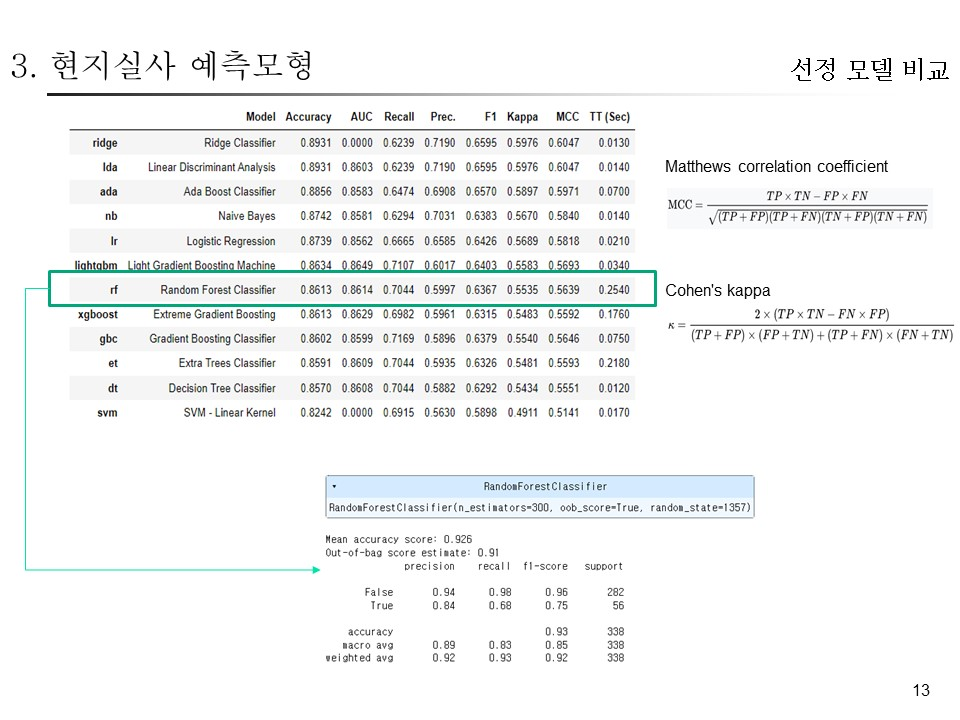

In [47]:
Image(filename= img_path + '/슬라이드13.JPG', width=width, height=height)

## CALIBRATION CURVE

In [179]:
data

,Predicted Probability,True Label
0,0.145848,0.0
1,0.456632,0.0
2,0.543431,0.0
3,0.438433,0.0
4,0.371923,0.0
...,...,...
333,0.492340,0.0
334,0.593778,0.0
335,0.456632,0.0
336,0.184748,0.0


In [48]:
data['A02_국가코드'] = woe.fit_transform(data['A02_국가코드'], data['target'])
X = data.iloc[:, :-1]
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y,  random_state=12)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, stratify=y_train, random_state=12)

  0%|          | 0/3 [00:00<?, ?it/s]

<AxesSubplot:title={'center':'Calibration plots (Reliability Curves)'}, xlabel='Mean predicted value', ylabel='Fraction of positives'>

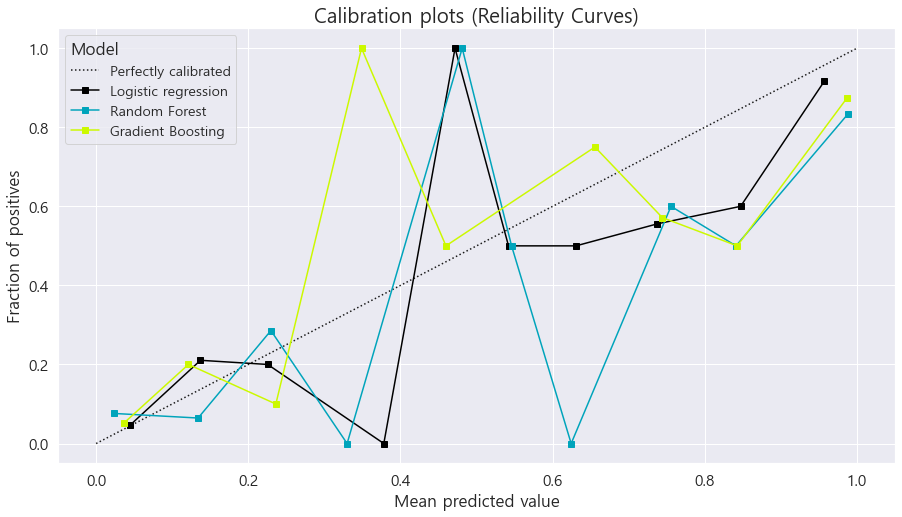

In [49]:
from tqdm import tqdm_notebook
import scikitplot as skplt

classifier_labels = []
probas_list = []
for classifier_label, classifier in tqdm_notebook(classifiers.items()):
    y_proba = classifier.fit(X_train, y_train).predict_proba(X_val)
    probas_list.append(y_proba)
    classifier_labels.append(classifier_label)

skplt.metrics.plot_calibration_curve(y_val, probas_list, classifier_labels, figsize=(15,8))
leg = plt.legend(title='Model', fontsize = 14)
leg._legend_box.align = 'left'

## 테스트데이터(X_test)에 적용하여 결과 확인 : BMT

In [50]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
# 성능지표
from sklearn.metrics import accuracy_score, plot_roc_curve 
from sklearn.metrics import plot_confusion_matrix, classification_report

import glob
glob.glob(path + '/*.*job*')

['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Gradient Boosting.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Logistic regression.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Random Forest.joblib']

### 최적 모델 불러오기

In [51]:
rf = load(glob.glob(path + '/*.*job*')[2])
rf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  Index([], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('woe_catencoder',
                                                                   WOEEncoder())]),
                                                  Index(['A02_국가코드'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=37,
                                        max_features='auto',
                                        min_samples_leaf=0.005,
                                        min_samples_split=0.05,
                                        n_estimators=150, n_jobs=-1))])

In [52]:
rf.get_params

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  Index([], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('woe_catencoder',
                                                                   WOEEncoder())]),
                                                  Index(['A02_국가코드'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=37,
                                        max_features='auto',
                                        min_samples_leaf=0.005,
                                        min_samples_split=0.05,
                

0.5976331360946746

              precision    recall  f1-score   support

       False       0.92      0.57      0.70       282
        True       0.26      0.75      0.38        56

    accuracy                           0.60       338
   macro avg       0.59      0.66      0.54       338
weighted avg       0.81      0.60      0.65       338



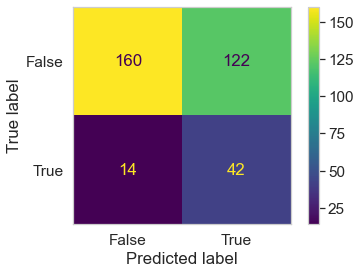

In [53]:
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)

## Decile 별로 부적합건수
- '1'은 부적합판정이 높은 percentile

array([[<AxesSubplot:title={'center':'probability_y'}>]], dtype=object)

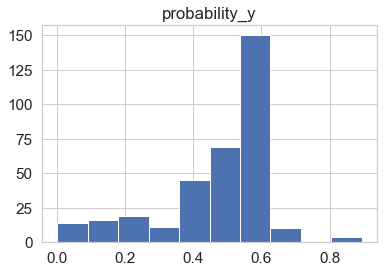

In [54]:
y_proba = rf.fit(X_train, y_train).predict_proba(X_test)
tf = pd.DataFrame({'actual_y' : y_test, 'probability_y' : y_proba[:, 1]}).sort_values('probability_y', ascending=False)
tf.hist()

Counter({False: 269, True: 2})

Text(0.5, 1.0, 'Distribution of probability of positive')

Text(0.5, 0, 'probability of positive')

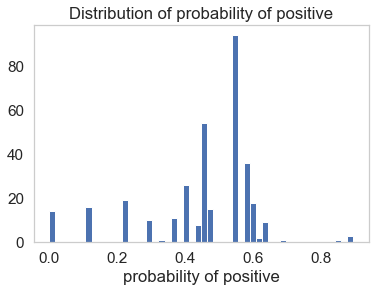

In [55]:
from collections import Counter
Counter(y_pred)
ax = plt.hist(y_proba[:, 1], bins=50)
plt.title('Distribution of probability of positive'); plt.xlabel('probability of positive')

<Figure size 720x360 with 0 Axes>

<AxesSubplot:xlabel='decile', ylabel='actual_y'>

Text(0.5, 1.0, 'Profit brought by each product decile')

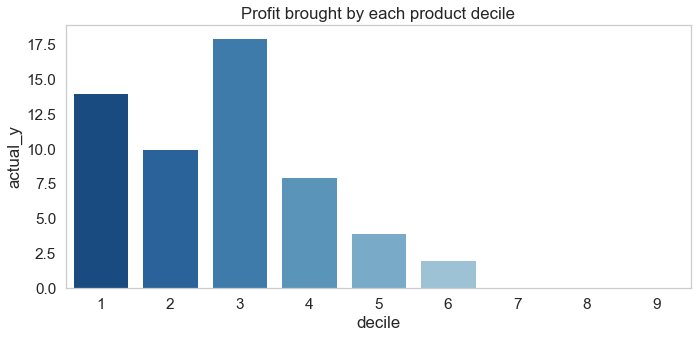

In [56]:
tf = pd.DataFrame({'actual_y' : y_test, 'probability_y' : y_proba[:, 1]}).sort_values('probability_y', ascending=False)
tf['decile'] = pd.qcut(tf["probability_y"], q = 6, labels = list(range(6, 0, -1)))

data = tf[['actual_y', 'decile']].groupby("decile").sum().reset_index().sort_values('decile', ascending=False)
plt.figure(figsize = (10,5))
sns.barplot(x = 'decile', y = 'actual_y', data = data, order = range(1, 10), palette = 'Blues_r')
plt.title("Profit brought by each product decile")
plt.tight_layout()

<AxesSubplot:title={'center':'Lift Curve'}, xlabel='Percentage of sample', ylabel='Lift'>

<AxesSubplot:title={'center':'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

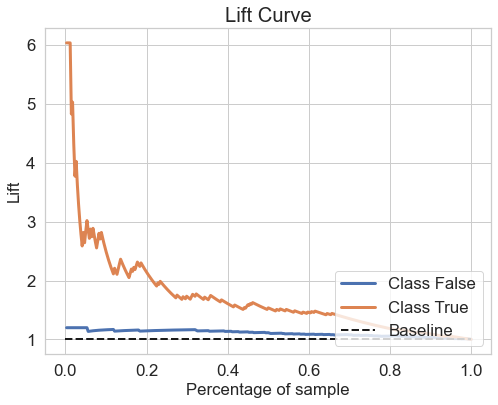

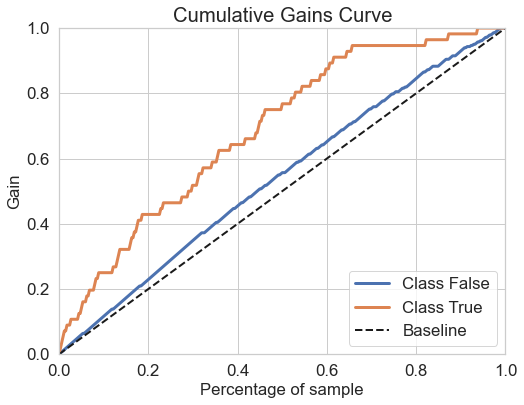

In [57]:
plt.rcParams["figure.figsize"] = (8,6)
y_proba = rf.predict_proba(X_test)
skplt.metrics.plot_lift_curve(y_test, y_proba)
skplt.metrics.plot_cumulative_gain(y_test, y_proba)

<AxesSubplot:title={'center':'KS Statistic Plot'}, xlabel='Threshold', ylabel='Percentage below threshold'>

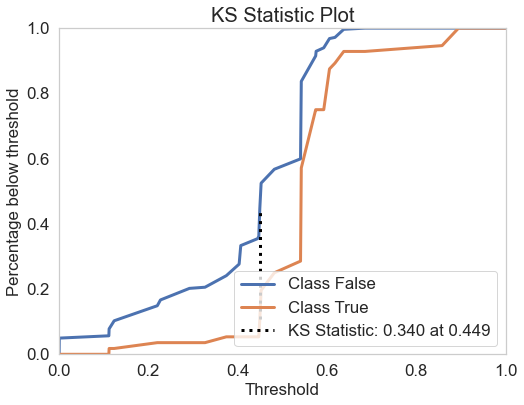

In [58]:
skplt.metrics.plot_ks_statistic(y_test, y_proba)

<AxesSubplot:title={'center':'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

<AxesSubplot:title={'center':'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

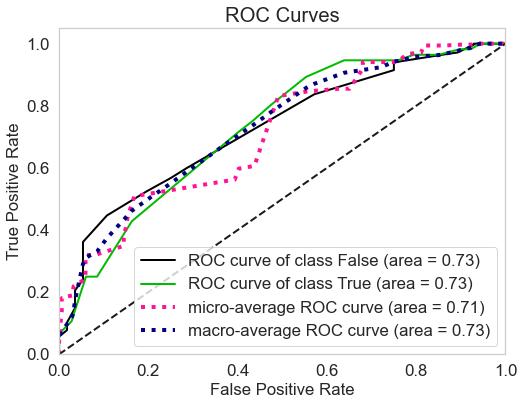

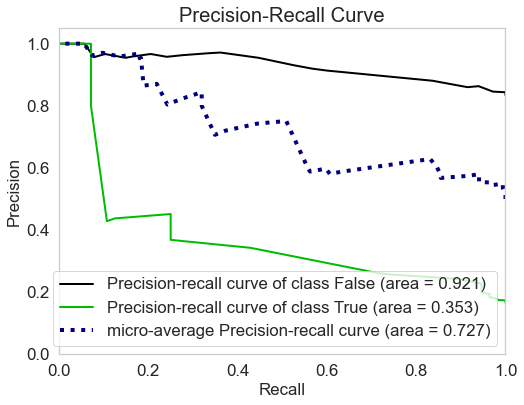

In [59]:
skplt.metrics.plot_roc(y_test, y_proba)
skplt.metrics.plot_precision_recall(y_test, y_proba)

In [60]:
from sklearn.metrics import precision_recall_curve
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')
p, r, thresholds = precision_recall_curve(y_test, y_proba[:, 1])
scores = [np.sum(to_labels(y_proba[:, 1], t))/len(y_proba[:, 1]) for t in thresholds]

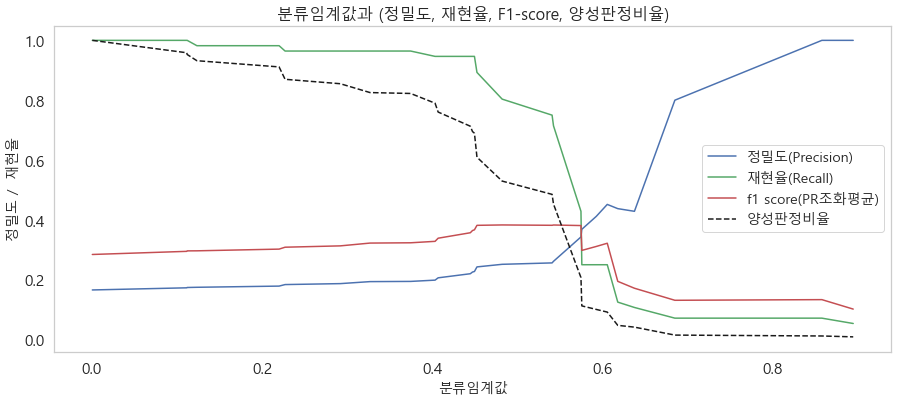

In [61]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds): 
    plt.rcParams["figure.figsize"] = (15,6)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    plt.title('분류임계값과 (정밀도, 재현율, F1-score, 양성판정비율)', fontsize='16') 
    plt.plot(thresholds, precisions[:-1], 'b-', label='정밀도(Precision)') # 판사
    plt.plot(thresholds, recalls[:-1], 'g-', label='재현율(Recall)') # 검사
    plt.plot(thresholds, (2*precisions[:-1]*recalls[:-1])/(precisions[:-1] +recalls[:-1]), 
             'r-', label='f1 score(PR조화평균)') # 변호사
    plt.plot(thresholds, scores, 'k--', label='양성판정비율') # q-ratio
    plt.ylabel('정밀도 /  재현율', fontsize='14') 
    plt.xlabel('분류임계값', fontsize='14') 
    plt.legend(loc='best', fontsize='14') 
plot_precision_recall_vs_threshold(p, r, thresholds)

<AxesSubplot:title={'center':'Learning Curve'}, xlabel='Training examples', ylabel='Score'>

<AxesSubplot:title={'center':'Learning Curve'}, xlabel='Training examples', ylabel='Score'>

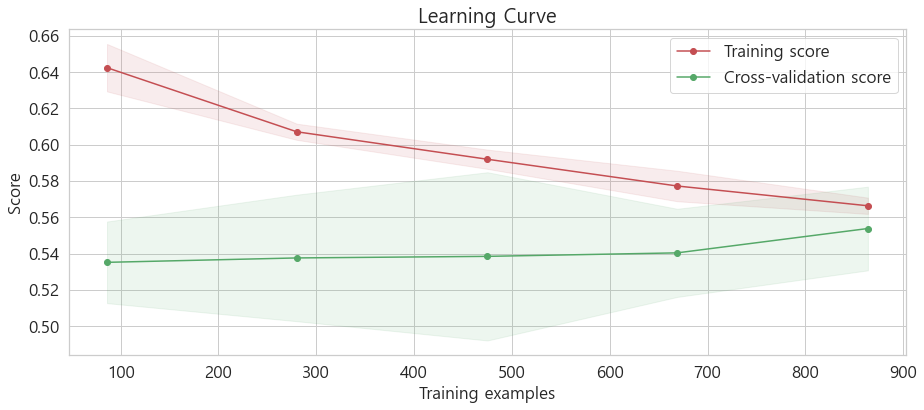

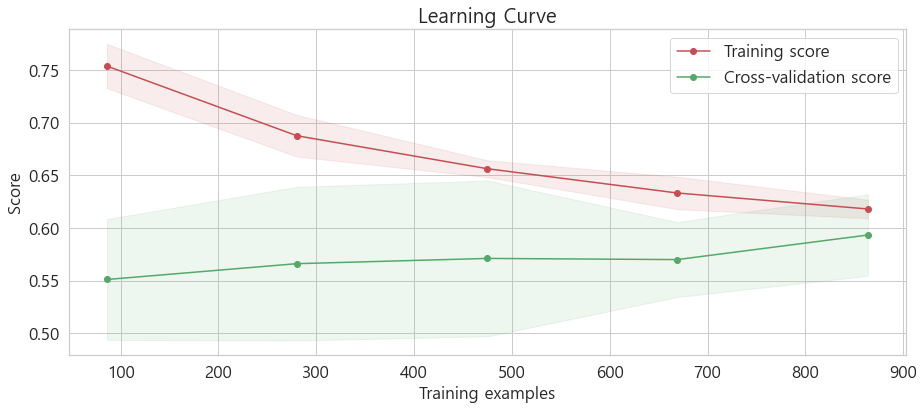

In [62]:
skplt.estimators.plot_learning_curve(rf, X_train, y_train, scoring='precision_macro')
skplt.estimators.plot_learning_curve(rf, X_train, y_train, scoring='recall_macro')

(array([ 23.,  15.,  16.,  10.,  17.,  84., 156.,  12.,   1.,   4.]),
 array([0.00400887, 0.08892366, 0.17383844, 0.25875323, 0.34366801,
        0.4285828 , 0.51349758, 0.59841237, 0.68332715, 0.76824194,
        0.85315673]),
 <BarContainer object of 10 artists>)

(array([  4.,   1.,  12., 156.,  84.,  17.,  10.,  16.,  15.,  23.]),
 array([0.14684327, 0.23175806, 0.31667285, 0.40158763, 0.48650242,
        0.5714172 , 0.65633199, 0.74124677, 0.82616156, 0.91107634,
        0.99599113]),
 <BarContainer object of 10 artists>)

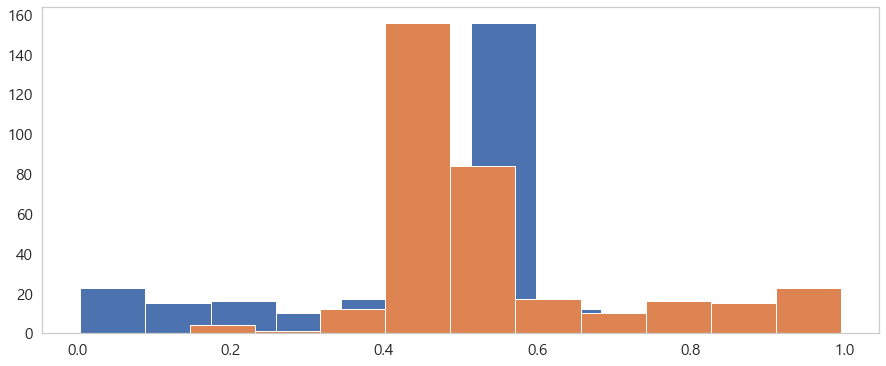

In [167]:
plt.hist(y_proba[:, 1]) 
plt.hist(y_proba[:, 0]) 

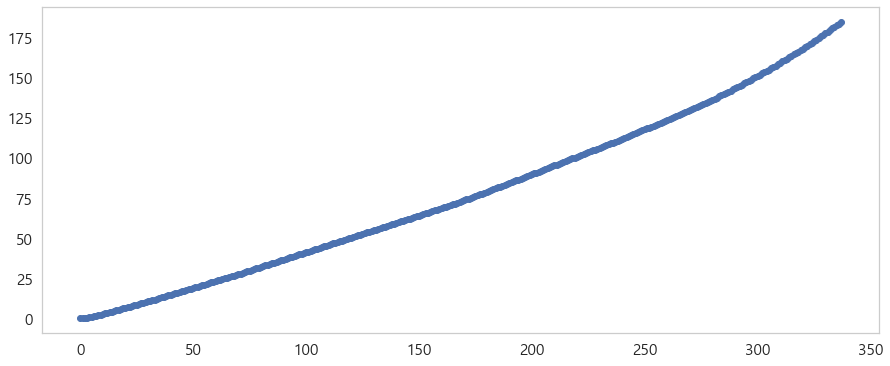

In [63]:
plt.scatter(np.arange(len(y_proba[:, 0])), np.sort(y_proba[:, 0]).cumsum()) 

In [169]:
rf.get_params

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  Index([], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('woe_catencoder',
                                                                   WOEEncoder())]),
                                                  Index(['A02_국가코드'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=30,
                                        max_features='auto',
                                        min_samples_leaf=0.005,
                                        min_samples_split=0.05, n_jobs=-1))])>

In [86]:
from sklearn.metrics import balanced_accuracy_score, recall_score, precision_score

acc_list = []
recall_list = []
precision_list= []

for i in np.random.choice(2500, 300, replace=False) :
    clf = ensemble.RandomForestClassifier(n_estimators = 30, random_state = i) 
    preds =  clf.fit(X_train, y_train).predict(X_val) 
    
    bal_acc = round(balanced_accuracy_score(y_true = y_val, y_pred = preds), 3)
    recall = round(recall_score(y_true= y_val, y_pred  = preds, average='macro'), 3)
    precision = round(precision_score(y_true= y_val, y_pred  = preds, average='macro'), 3)
    
    acc_list.append(bal_acc)
    recall_list.append(recall)
    precision_list.append(precision)

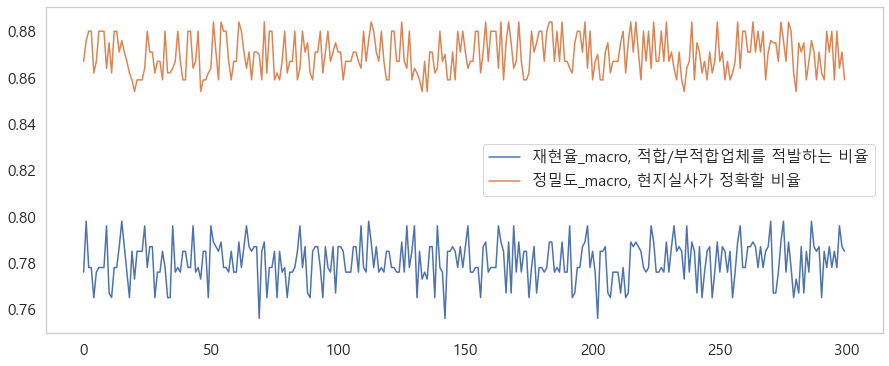

In [115]:
plt.plot(recall_list, label='재현율_macro, 적합/부적합업체를 적발하는 비율')
plt.plot(precision_list, label='정밀도_macro, 현지실사가 정확할 비율')
plt.legend()

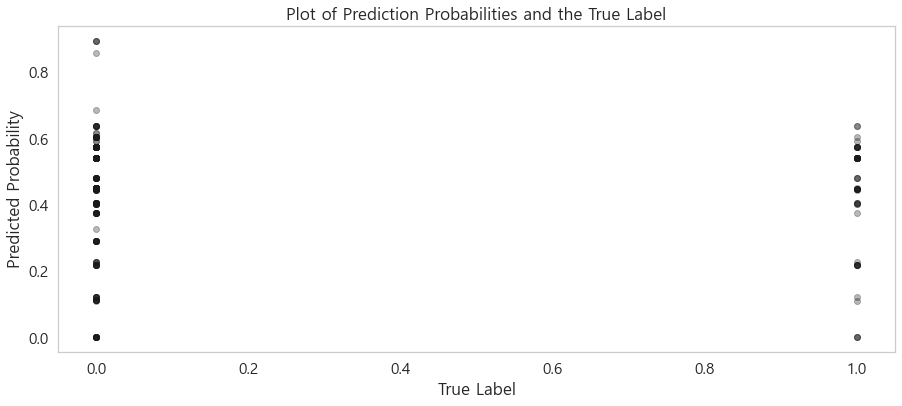

In [120]:
data = pd.DataFrame(np.c_[y_proba[:,1], y_test], columns=['Predicted Probability','True Label'])

ax = sns.regplot(x="True Label", y="Predicted Probability", color='k', 
                 fit_reg=False, scatter_kws={'alpha':0.3},
                 data=data).set_title('Plot of Prediction Probabilities and the True Label')

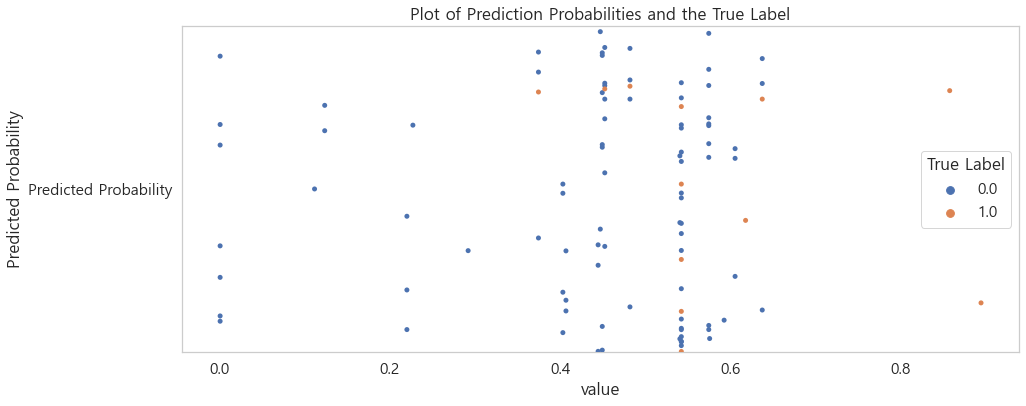

In [68]:
datamelted = pd.melt(data, "True Label", var_name="Predicted Probability")
ax = sns.stripplot(x="value", y="Predicted Probability",
                   hue='True Label', jitter=0.5, 
                   data=datamelted.sample(100, random_state=13)).set_title('Plot of Prediction Probabilities and the True Label')

RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)

<Figure size 1800x360 with 0 Axes>

Text(0, 0.5, 'Features Importance')

Text(0.5, 1.0, '변수 중요도')

([<matplotlib.axis.XTick at 0x17f6b841820>,
 [Text(0, 0, 'A02_국가코드'),
  Text(1, 0, '대표자성명'),
  Text(2, 0, '주소'),
  Text(3, 0, '전화번호'),
  Text(4, 0, '이메일'),
  Text(5, 0, '회사이메일'),
  Text(6, 0, '팩스'),
  Text(7, 0, '인증'),
  Text(8, 0, '공식인증'),
  Text(9, 0, '수산물'),
  Text(10, 0, 'N'),
  Text(11, 0, 'S'),
  Text(12, 0, 'Y')])

<BarContainer object of 13 artists>

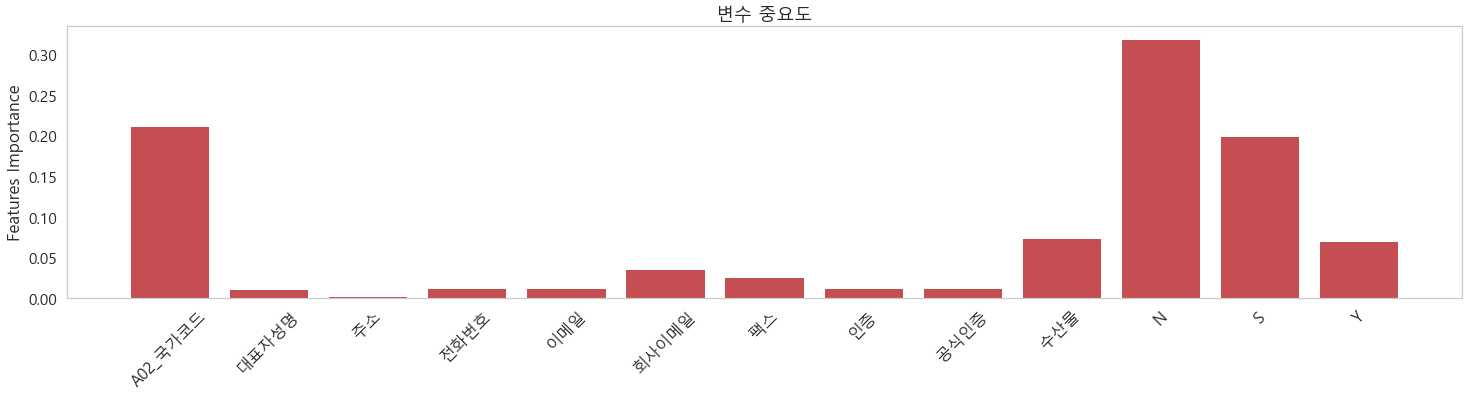

In [69]:
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, 
                                                  stratify= y, random_state=11)
dt = ensemble.RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)
dt.fit(X, y)
plt.figure(figsize=(25,5)); plt.ylabel('Features Importance')
plt.title('변수 중요도', fontsize=18)
plt.xticks(np.arange(X.shape[1]), X.columns, rotation='45', fontsize=16)
plt.bar(range(X.shape[1]), dt.feature_importances_, color='r')

## 로지스틱회귀모형으로 해석

In [70]:
model = LogisticRegression(solver='saga', random_state=11)
params = {'C': np.logspace(-4, 4, 20), 'penalty': ['l1', 'l2']}
grid = RandomizedSearchCV(model, param_distributions=params, cv=kf,
                          scoring = 'recall')
grid.fit(X_train, y_train)
print('optimal train score: {:.3f}'.format(grid.best_score_))
print('test score: {:.3f}'.format(grid.score(X_test, y_test)))
print('optimal parameter: {}'.format(grid.best_params_))

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=LogisticRegression(random_state=11, solver='saga'),
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2']},
                   scoring='recall')

optimal train score: 0.603
test score: 0.679
optimal parameter: {'penalty': 'l2', 'C': 78.47599703514607}


In [71]:
model= LogisticRegression(random_state=11, solver='saga').set_params(**grid.best_params_)
model.fit(X_train, y_train)


LogisticRegression(C=78.47599703514607, random_state=11, solver='saga')

In [72]:
model.intercept_
model.coef_

array([-2.16562902])

array([[ 1.10003081,  0.67269714,  0.54579072,  1.14953007,  0.90539996,
        -0.54283188, -0.11329521, -1.55829506,  1.22789652, -1.99923858,
        -2.99248323,  1.27399414, -0.16553165]])

<AxesSubplot:xlabel='variable'>

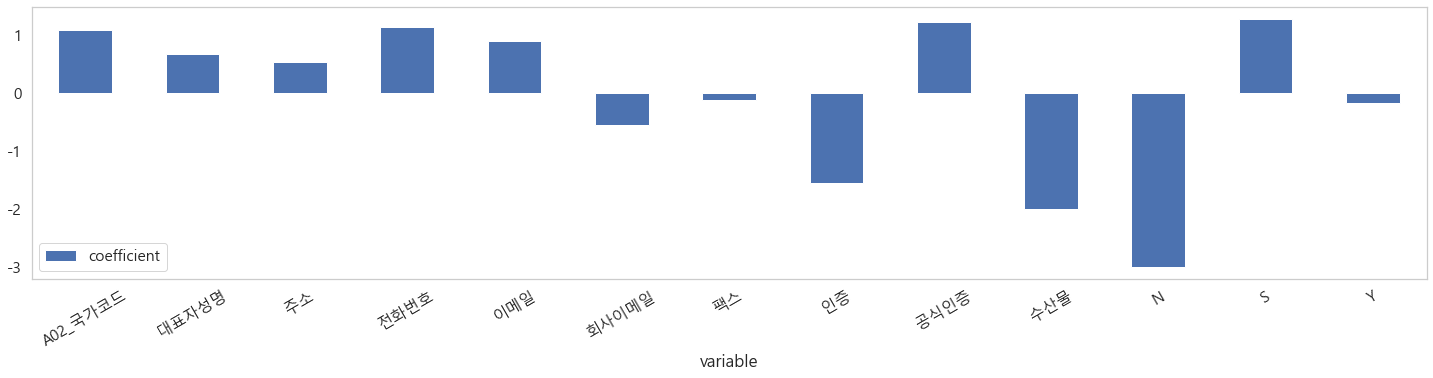

In [73]:
data = zip(X_train.columns, np.squeeze(model.coef_))
(pd.DataFrame(data, columns =['variable', 'coefficient']).set_index('variable').
plot.bar(rot='30', figsize=(25,5)))

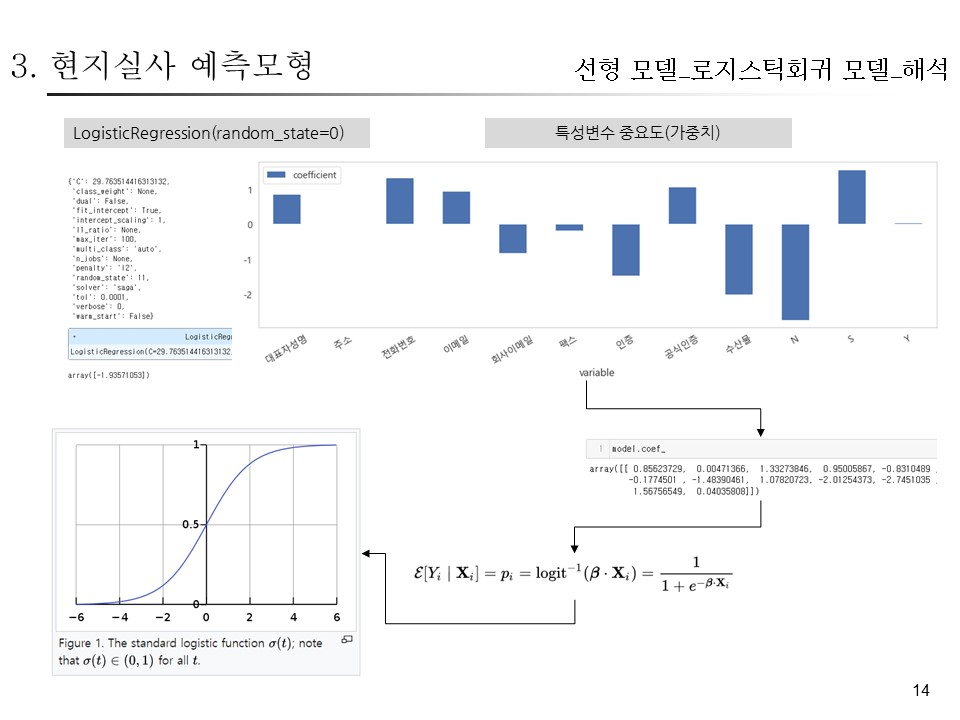

In [153]:
Image(filename= img_path + '/슬라이드14.JPG', width=width, height=height)

# SHAP
## SHAP (SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model
https://github.com/slundberg/shap

<img src='https://raw.githubusercontent.com/slundberg/shap/master/docs/artwork/shap_header.svg' width=600 height=400>

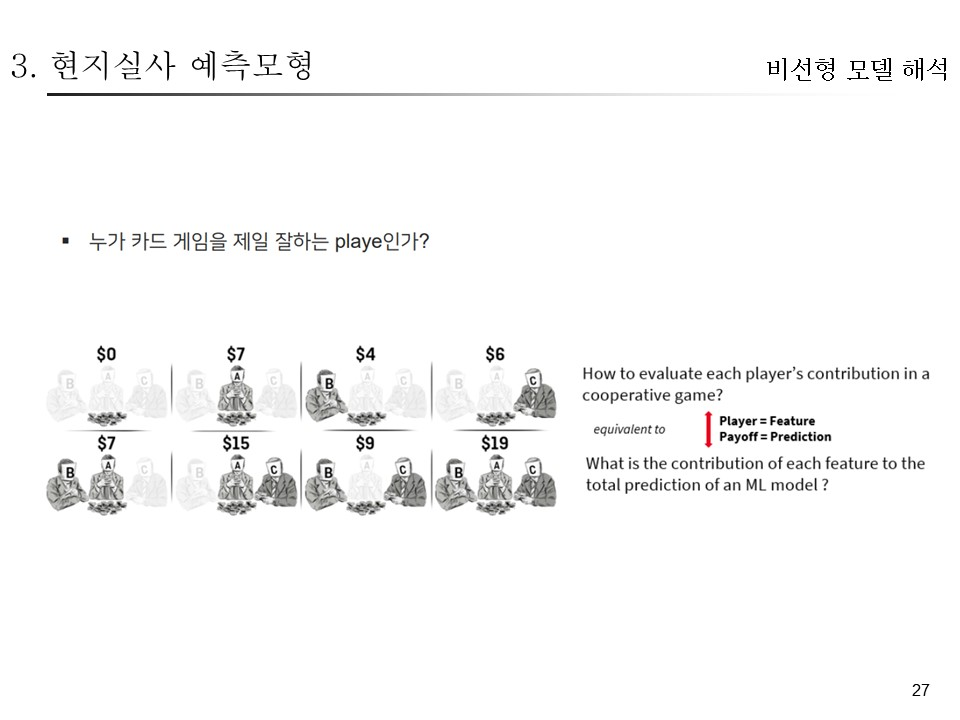

In [155]:
Image(filename= img_path + '/슬라이드27.JPG', width=width, height=height)

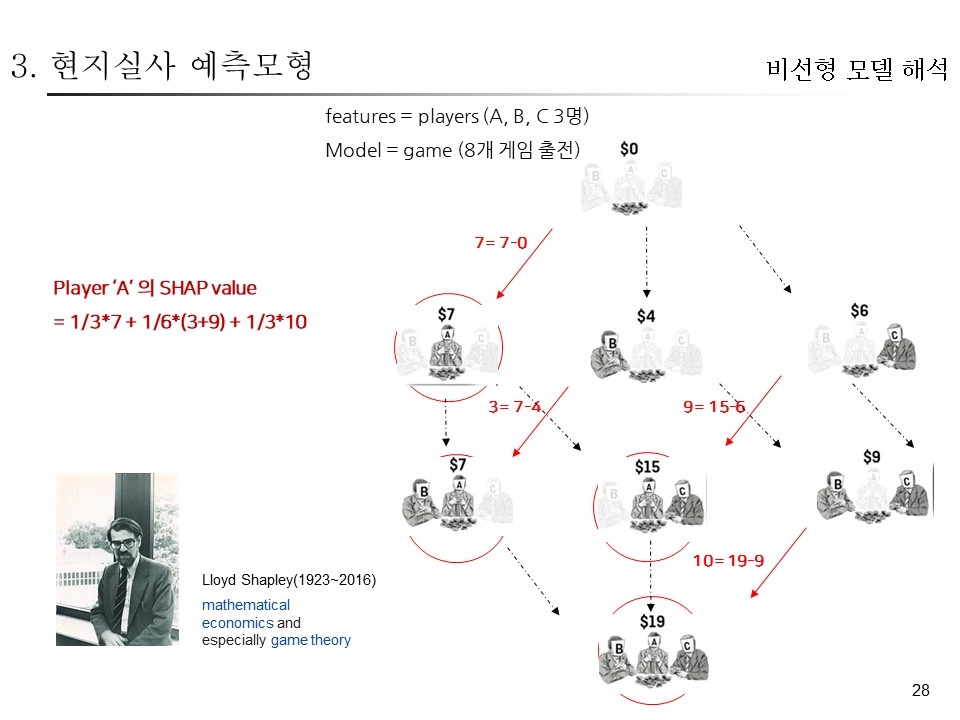

In [156]:
Image(filename= img_path + '/슬라이드28.JPG', width=width, height=height)

In [110]:
import xgboost
import shap
# train an XGBoost model
#X, y =shap.datasets.adult()
X.head(10)
y[0:10]

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y
0,True,True,True,True,False,False,False,False,False,True,False,False
1,True,True,True,True,False,False,False,False,False,True,False,False
2,True,True,True,True,True,True,False,False,False,True,False,False
3,True,True,True,True,True,False,False,False,False,True,False,False
4,True,True,True,True,False,True,True,True,False,False,False,True
5,True,True,True,True,True,True,True,True,False,True,False,False
6,True,True,True,True,False,False,False,False,False,False,True,False
7,True,True,True,True,True,False,False,False,False,True,False,False
8,True,True,True,True,True,True,False,False,False,True,False,False
9,True,True,True,True,True,True,True,True,False,True,False,False


0    False
1    False
2    False
3    False
4    False
5    False
6     True
7    False
8    False
9    False
Name: target, dtype: bool

.values =
array([ 1.0381656e-02, -2.3209922e-04,  1.7782761e-02,  1.7344324e-02,
        6.3805431e-01,  5.8674213e-02, -6.2427752e-02,  1.4393292e-01,
        1.5224051e-01, -5.7675129e-01, -8.3331987e-02,  4.0792935e-03],
      dtype=float32)

.base_values =
-1.981489

.data =
array([ True,  True,  True,  True, False, False, False, False, False,
        True, False, False])

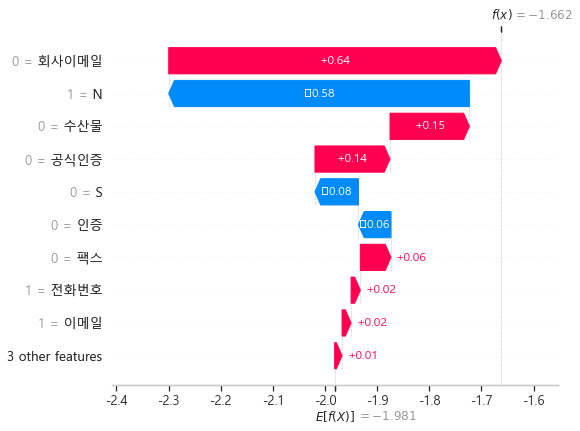

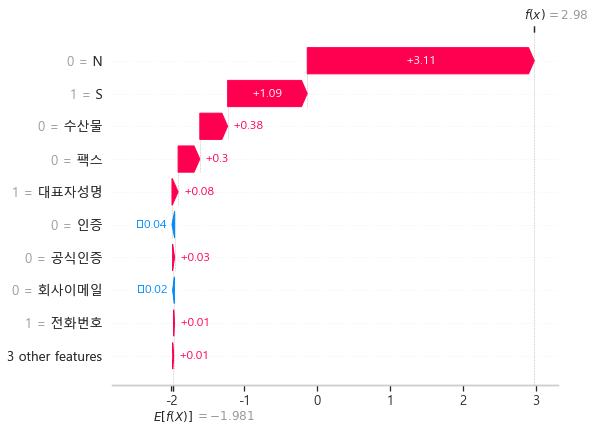

In [138]:
model = xgboost.XGBClassifier(eval_metric='mlogloss').fit(X, y)
explainer = shap.Explainer(model) # explainer = shap.Explainer(model, X)
shap_values = explainer(X)
shap_values[0]
shap.plots.waterfall(shap_values[0])
shap.plots.waterfall(shap_values[6])

In [140]:
explainer = shap.TreeExplainer(model) 
shap_values = explainer.shap_values(X)
shap.initjs()
shap.plots.force(explainer.expected_value, shap_values[0])
shap.plots.force(explainer.expected_value, shap_values[6])

In [141]:
shap_values
print(f'\n\n원자료의 크기{X.shape}와 SHAP value의 크기{shap_values.shape}')

array([[ 1.03816558e-02, -2.32099221e-04,  1.77827608e-02, ...,
        -5.76751292e-01, -8.33319873e-02,  4.07929346e-03],
       [ 1.03816558e-02, -2.32099221e-04,  1.77827608e-02, ...,
        -5.76751292e-01, -8.33319873e-02,  4.07929346e-03],
       [ 1.66005399e-02, -2.99372594e-04,  1.22792488e-02, ...,
        -6.08922541e-01, -1.29786968e-01,  5.70906326e-03],
       ...,
       [ 1.74639486e-02, -2.63769180e-04,  1.40949460e-02, ...,
        -6.94128096e-01, -1.27698302e-01, -7.80159608e-03],
       [ 1.59846842e-02, -2.51979276e-04,  1.32445805e-02, ...,
        -5.64298272e-01, -1.53642759e-01,  9.12466366e-03],
       [ 1.59846842e-02,  2.90983059e-02,  1.31562594e-02, ...,
        -5.64298272e-01, -1.53642759e-01,  5.22305584e-03]], dtype=float32)



원자료의 크기(1689, 12)와 SHAP value의 크기(1689, 12)


In [142]:
data = pd.DataFrame(shap_values, columns = X.columns)
data['sum of SHAP'] = data.sum(1)  # 특성 변수의 SHAP values
data['average mean of model prediction'] = np.mean(model.predict(X))
data['prediction value by shap'] = data['sum of SHAP'] + data['average mean of model prediction']
#data['prediction by model'] = model.predict(X)
data['prediction by model'] = model.predict(X)

In [143]:
data.head(10)
shap_values[0]
shap_values[6]

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,sum of SHAP,average mean of model prediction,prediction value by shap,prediction by model
0,0.010382,-0.000232,0.017783,0.017344,0.638054,0.058674,-0.062428,0.143933,0.152241,-0.576751,-0.083332,0.004079,0.319747,0.113085,0.432832,False
1,0.010382,-0.000232,0.017783,0.017344,0.638054,0.058674,-0.062428,0.143933,0.152241,-0.576751,-0.083332,0.004079,0.319747,0.113085,0.432832,False
2,0.016601,-0.000299,0.012279,0.005168,-0.600591,-0.165883,0.053174,-0.115983,0.284141,-0.608923,-0.129787,0.005709,-1.244395,0.113085,-1.131310,False
3,0.016841,-0.000177,0.015180,0.009160,-0.442152,0.187368,0.038118,0.023618,0.144584,-0.658546,-0.130841,0.004295,-0.792551,0.113085,-0.679466,False
4,0.128722,-0.000262,0.012712,0.005587,-0.017998,0.061702,-0.425770,-0.012166,0.286549,2.332754,-0.475846,-0.050349,1.845634,0.113085,1.958719,False
5,0.017464,-0.000264,0.014095,0.005792,-0.359580,0.014154,-0.057443,0.157720,0.271959,-0.694128,-0.127698,-0.007802,-0.765730,0.113085,-0.652645,False
6,0.084166,-0.000232,0.009669,0.009641,-0.024451,0.297749,-0.035820,0.027432,0.381617,3.114963,1.092446,0.004079,4.961259,0.113085,5.074344,True
7,0.016841,-0.000177,0.015180,0.009160,-0.442152,0.187368,0.038118,0.023618,0.144584,-0.658546,-0.130841,0.004295,-0.792551,0.113085,-0.679466,False
8,0.016601,-0.000299,0.012279,0.005168,-0.600591,-0.165883,0.053174,-0.115983,0.284141,-0.608923,-0.129787,0.005709,-1.244395,0.113085,-1.131310,False
9,0.017464,-0.000264,0.014095,0.005792,-0.359580,0.014154,-0.057443,0.157720,0.271959,-0.694128,-0.127698,-0.007802,-0.765730,0.113085,-0.652645,False


array([ 1.0381656e-02, -2.3209922e-04,  1.7782761e-02,  1.7344324e-02,
        6.3805431e-01,  5.8674213e-02, -6.2427752e-02,  1.4393292e-01,
        1.5224051e-01, -5.7675129e-01, -8.3331987e-02,  4.0792935e-03],
      dtype=float32)

array([ 8.4165625e-02, -2.3209922e-04,  9.6690962e-03,  9.6412878e-03,
       -2.4450889e-02,  2.9774892e-01, -3.5820067e-02,  2.7432149e-02,
        3.8161728e-01,  3.1149628e+00,  1.0924460e+00,  4.0792935e-03],
      dtype=float32)

In [147]:
data = pd.DataFrame(shap_values, columns = X.columns)
data['SUM'] = data.sum(1)  # 특성 변수의 SHAP values
data['f(x)'] = model.predict(X)
data['E[f(x)]'] = np.mean(model.predict(X))
data['SUM + E[f(x)]'] = data['SUM'] + data['E[f(x)]']
data.head(10)

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,SUM,f(x),E[f(x)],SUM + E[f(x)]
0,0.010382,-0.000232,0.017783,0.017344,0.638054,0.058674,-0.062428,0.143933,0.152241,-0.576751,-0.083332,0.004079,0.319747,False,0.113085,0.432832
1,0.010382,-0.000232,0.017783,0.017344,0.638054,0.058674,-0.062428,0.143933,0.152241,-0.576751,-0.083332,0.004079,0.319747,False,0.113085,0.432832
2,0.016601,-0.000299,0.012279,0.005168,-0.600591,-0.165883,0.053174,-0.115983,0.284141,-0.608923,-0.129787,0.005709,-1.244395,False,0.113085,-1.131310
3,0.016841,-0.000177,0.015180,0.009160,-0.442152,0.187368,0.038118,0.023618,0.144584,-0.658546,-0.130841,0.004295,-0.792551,False,0.113085,-0.679466
4,0.128722,-0.000262,0.012712,0.005587,-0.017998,0.061702,-0.425770,-0.012166,0.286549,2.332754,-0.475846,-0.050349,1.845634,False,0.113085,1.958719
5,0.017464,-0.000264,0.014095,0.005792,-0.359580,0.014154,-0.057443,0.157720,0.271959,-0.694128,-0.127698,-0.007802,-0.765730,False,0.113085,-0.652645
6,0.084166,-0.000232,0.009669,0.009641,-0.024451,0.297749,-0.035820,0.027432,0.381617,3.114963,1.092446,0.004079,4.961259,True,0.113085,5.074344
7,0.016841,-0.000177,0.015180,0.009160,-0.442152,0.187368,0.038118,0.023618,0.144584,-0.658546,-0.130841,0.004295,-0.792551,False,0.113085,-0.679466
8,0.016601,-0.000299,0.012279,0.005168,-0.600591,-0.165883,0.053174,-0.115983,0.284141,-0.608923,-0.129787,0.005709,-1.244395,False,0.113085,-1.131310
9,0.017464,-0.000264,0.014095,0.005792,-0.359580,0.014154,-0.057443,0.157720,0.271959,-0.694128,-0.127698,-0.007802,-0.765730,False,0.113085,-0.652645


In [157]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values)

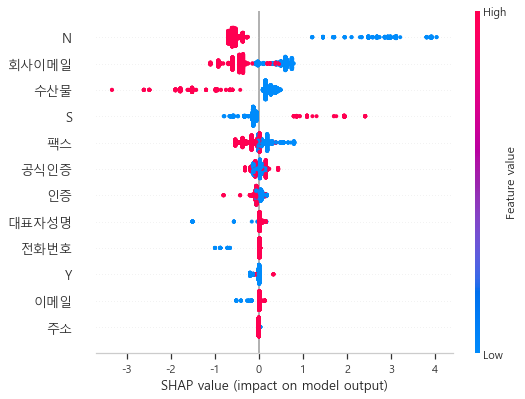

In [79]:
shap.summary_plot(shap_values, X)

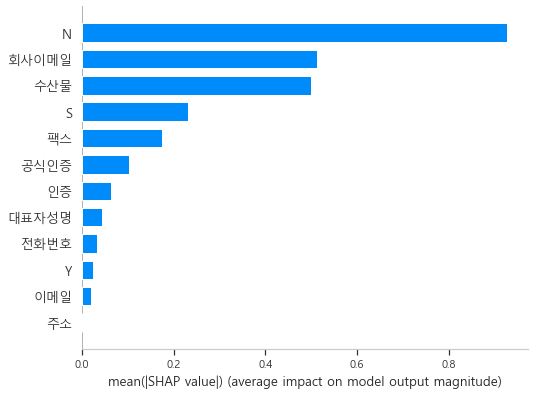

In [80]:
shap.summary_plot(shap_values, X, plot_type="bar")

# 향후 계획(2023년도)

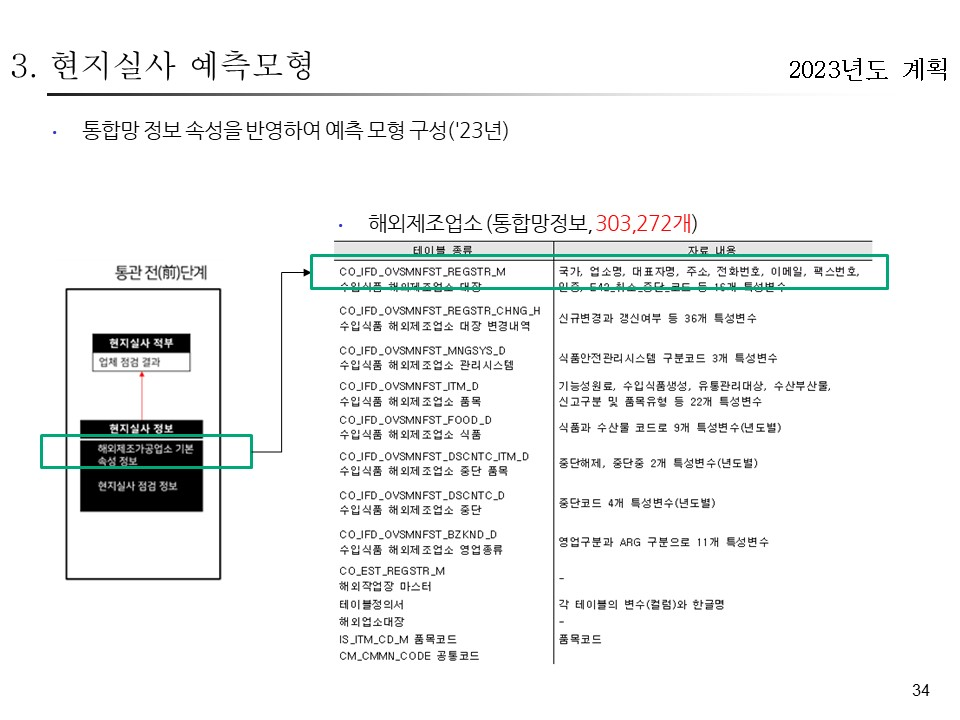

In [157]:
Image(filename= img_path + '/슬라이드34.JPG', width=width, height=height)

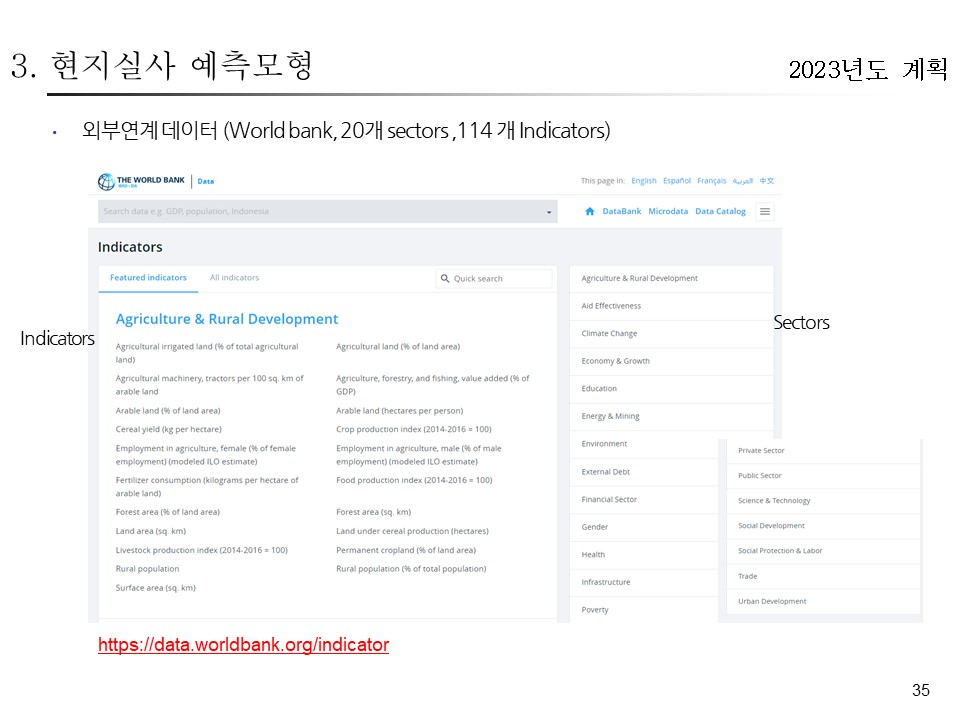

In [158]:
Image(filename= img_path + '/슬라이드35.JPG', width=width, height=height)

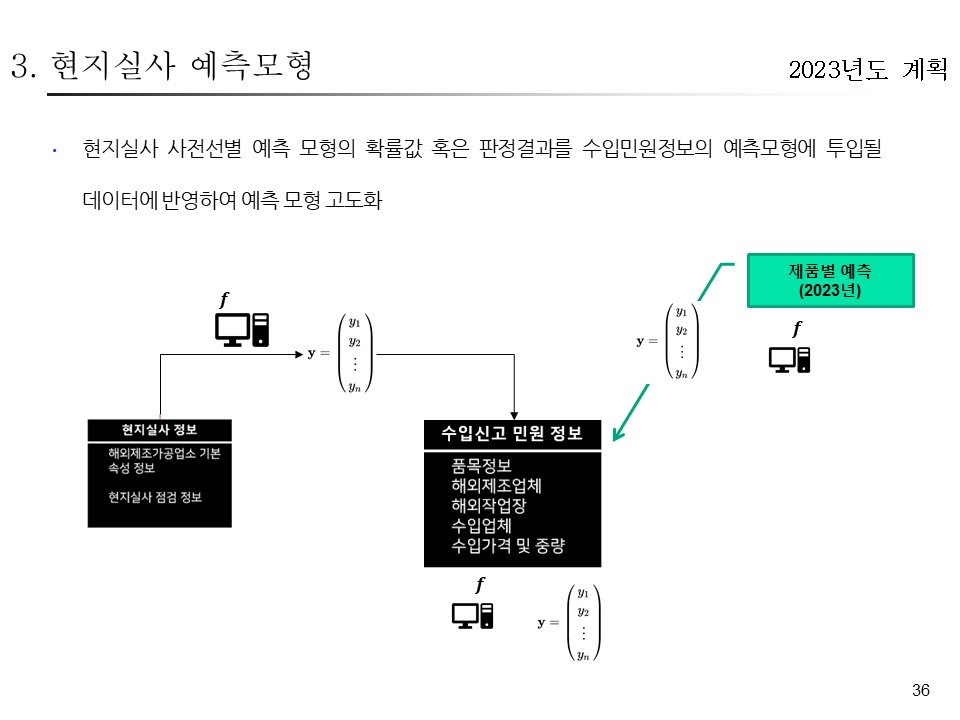

In [159]:
Image(filename= img_path + '/슬라이드36.JPG', width=width, height=height)

# Pycaret

In [2]:
# https://pycaret.gitbook.io/docs/#classification
# 준비
from pycaret.classification import *
import pandas as pd

In [29]:
data = pd.read_pickle('../working_ml/data_01_대장.pkl').reset_index(drop=True).iloc[:,2:]
data

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
0,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
1,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
2,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
3,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
4,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1685,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1686,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False
1687,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False


In [30]:
# data.drop(['업소명','R','N','S'], axis=1, inplace=True)
data.drop(['업소명','R'], axis=1, inplace=True)

In [31]:
data.corr().shape

(13, 13)

In [32]:
train = data.sample(frac=0.8)
test = data[~data.index.isin(train.index)]

In [33]:
train.shape, test.shape

((1351, 13), (338, 13))

In [34]:
clf1 = setup(data = train, target = 'target', silent=True, fix_imbalance=True)

,Description,Value
0,session_id,344
1,Target,target
2,Target Type,Binary
3,Label Encoded,"False: 0, True: 1"
4,Original Data,"(1351, 13)"
5,Missing Values,False
6,Numeric Features,0
7,Categorical Features,12
8,Ordinal Features,False
9,High Cardinality Features,False


In [35]:
# model training and selection
# best = compare_models()
# best = compare_models(include=['knn'])
best = compare_models(exclude=['knn','qda','dummy'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.8931,0.0000,0.6239,0.7190,0.6595,0.5976,0.6047,0.0130
lda,Linear Discriminant Analysis,0.8931,0.8603,0.6239,0.7190,0.6595,0.5976,0.6047,0.0140
ada,Ada Boost Classifier,0.8856,0.8583,0.6474,0.6908,0.6570,0.5897,0.5971,0.0700
nb,Naive Bayes,0.8742,0.8581,0.6294,0.7031,0.6383,0.5670,0.5840,0.0140
lr,Logistic Regression,0.8739,0.8562,0.6665,0.6585,0.6426,0.5689,0.5818,0.0210
lightgbm,Light Gradient Boosting Machine,0.8634,0.8649,0.7107,0.6017,0.6403,0.5583,0.5693,0.0340
rf,Random Forest Classifier,0.8613,0.8614,0.7044,0.5997,0.6367,0.5535,0.5639,0.2540
xgboost,Extreme Gradient Boosting,0.8613,0.8629,0.6982,0.5961,0.6315,0.5483,0.5592,0.1760
gbc,Gradient Boosting Classifier,0.8602,0.8599,0.7169,0.5896,0.6379,0.5540,0.5646,0.0750
et,Extra Trees Classifier,0.8591,0.8609,0.7044,0.5935,0.6326,0.5481,0.5593,0.2180


In [36]:
# 모델 평가
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [37]:
interpret_model(best, plot = 'pfi')

12it [00:00, 73.51it/s]


In [13]:
# test set으로 예측
predictions = predict_model(best, data = test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.9201,0.8422,0.6607,0.8222,0.7327,0.6864,0.6920


In [14]:
predictions

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,S,Y,target,Label,Score
11,True,True,True,True,False,True,False,False,False,True,False,True,True,1.0
13,True,True,True,True,True,False,True,True,False,False,False,False,False,1.0
19,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0
30,True,True,True,True,False,False,False,False,False,False,False,False,False,1.0
32,True,True,True,True,False,True,False,False,False,False,False,False,False,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,True,True,True,True,True,True,True,True,False,False,False,False,False,1.0
1670,True,True,True,True,True,False,False,False,False,False,False,True,False,1.0
1674,True,True,True,True,False,True,False,False,False,False,True,True,True,0.6
1679,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0


In [15]:
predictions['target'].value_counts()

False    282
True      56
Name: target, dtype: int64

In [16]:
# predictions['Label'].replace({'False':False,'True':True})

In [17]:
predictions.groupby('target').Label.value_counts().unstack()

Label,False,True
target,,
False,274,8
True,19,37


In [16]:
test

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,...,NV.IND.TOTL.ZS,NY.GDP.DEFL.KD.ZG,NY.GDP.PCAP.CD,NY.GDP.PCAP.KD.ZG,SL.EMP.TOTL.SP.ZS,SL.UEM.TOTL.ZS,SP.DYN.LE00.IN,SP.URB.TOTL.IN.ZS,TG.VAL.TOTL.GD.ZS,target
3,True,True,True,True,False,True,False,False,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
5,True,True,True,True,False,False,True,True,False,False,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
9,True,True,True,True,True,True,True,True,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,False
21,True,True,True,True,False,False,False,False,False,False,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
26,True,True,True,True,False,True,True,True,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,True,True,True,True,False,False,False,False,True,True,...,23.311218,39.891217,8579.017773,-10.765108,53.814999,10.902000,76.813,92.111,24.978419,False
1661,True,True,True,True,True,False,False,False,True,True,...,23.311218,39.891217,8579.017773,-10.765108,53.814999,10.902000,76.813,92.111,24.978419,False
1665,True,True,True,True,False,False,False,False,False,True,...,21.688295,5.067760,3521.591948,-10.134432,38.179001,16.823999,76.891,69.568,77.279504,False
1684,True,True,True,True,True,True,False,False,True,True,...,32.004504,-0.923994,5600.389615,-9.158745,60.669998,6.427000,77.216,64.166,38.646664,False


In [17]:
best.predict_proba(test.iloc[:,:-1])

array([[0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.

In [18]:
(best.predict_proba(test.iloc[:,:-1])>0.99).mean(axis=0)

array([0., 0.])

<AxesSubplot:ylabel='Frequency'>

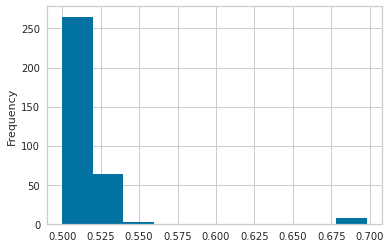

In [20]:
predictions['Score'].plot.hist()

In [21]:
# 결과 평가
(predictions['target']==predictions['Label'].replace({'False':False, 'True':True})).mean()

0.9023668639053254

In [22]:
predictions['Label'].replace({'False':False, 'True':True}).mean()

0.14792899408284024

# End